# Table of contents

* **Introduction**
* **Objective**
* **Ridge Foundations**
* **Data dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training and Experiments**
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

Ridge Classification (RidgeClassifier) represents a linear model that extends the principles of ridge regression to solve classification problems. This approach involves internally transforming multi-class labels into a binary scheme (one-versus-rest) and subsequently fitting a regularized least-squares model. The core mechanism involves L2 regularization (controlled by the hyperparameter alpha), which functions to shrink the magnitude of feature coefficients. This process is particularly valuable for mitigating overfitting when the dataset features exhibit high correlation (multicollinearity) or when a simplified, stable baseline prediction model is required.

Despite its origin in regression, the RidgeClassifier is fully supported within scikit-learn's API for multi-class tasks, integrating seamlessly with advanced components like preprocessing tools, cross-validation, and hyperparameter optimization routines. This document outlines a complete, end-to-end workflow utilizing the RidgeClassifier on a real-world healthcare dataset, predicting patient hospital stay duration across 11 classes, adhering strictly to official scikit-learn best practices and documentation.

# Objective

The project's objective is to construct, train, tune, and rigorously evaluate a multi-class classification model using `sklearn.linear_model.RidgeClassifier` on a challenging, imbalanced healthcare dataset. The specific aims include:

- Demonstrating the appropriate preprocessing methodology for mixed-type (numerical and categorical) data.
- Implementing proper strategies for handling missing data and addressing inherent class imbalance.
- Developing efficient, reusable machine learning pipelines using scikit-learn components.
- Performing efficient hyperparameter optimization via Bayesian Search (`BayesSearchCV`).
- Conducting rigorous model evaluation using stratified cross-validation and a comprehensive suite of classification metrics.
- Generating visualizations to interpret the model’s decision boundaries and its functional behavior on individual features.

# Ridge Foundations

**Ridge Classification for Multi-Class Problems**

Ridge Classification (RidgeClassifier) is a robust linear model widely used as an efficient and interpretable baseline for classification tasks, particularly in high-dimensional or multicollinear datasets. Its theoretical foundation is derived from Ridge Regression, adapted for categorical outcomes.

**1. Core Mechanism: Regularized Least Squares**

The Ridge Classifier functions by solving an optimization problem that is structurally similar to finding the coefficients in a least-squares fit, but with an added penalty term.
- Underlying Principle (Least Squares): The model seeks to find a set of coefficients $\mathbf{w}$ that minimizes the squared difference between the predicted output $\mathbf{\hat{y}}$ and the true target values $\mathbf{y}$.
- Classification Adaptation: For classification, the objective is to minimize the function:$$J(\mathbf{w}) = \frac{1}{2} ||X\mathbf{w} - \mathbf{y}||^2 + \alpha ||\mathbf{w}||^2_2$$The term $\frac{1}{2} ||X\mathbf{w} - \mathbf{y}||^2$ represents the standard squared error loss (the fit to the data).

**2. The Role of L2 Regularization (Ridge Penalty)**

The defining characteristic of the Ridge Classifier is the $\mathbf{L2}$ penalty, the second term in the objective function ($+\alpha ||\mathbf{w}||^2_2$).
- Mechanism: L2 regularization adds a penalty equal to the square of the magnitude of the coefficient vector, scaled by a hyperparameter $\alpha$.
- Coefficient Shrinkage: The penalty forces the optimization algorithm to keep coefficient magnitudes small. This shrinkage prevents any single feature from disproportionately influencing the prediction, a key measure against overfitting.
- Multicollinearity Handling: L2 regularization is highly effective when features are highly correlated (multicollinear). Instead of allowing one correlated feature to have a large coefficient and the others to have near-zero coefficients, L2 regularization distributes the importance more evenly among the correlated features, leading to a more stable and generalized model.
- The $\alpha$ Parameter: The regularization strength is controlled by $\alpha$ (sometimes denoted as $\lambda$ or alpha in scikit-learn).
    - $\alpha \rightarrow 0$: The model approaches standard linear least squares (no penalty).
    - $\alpha \rightarrow \infty$: The coefficients $\mathbf{w}$ are driven towards zero (strong penalty).
    - Optimal performance requires tuning $\alpha$ to find the best trade-off between bias (underfitting) and variance (overfitting).

**3. Multi-Class Classification Strategy (One-vs-Rest)**

Since Ridge Regression is fundamentally a model for continuous output, it must employ a strategy to handle categorical multi-class problems:

- One-vs-Rest (OvR) Strategy: The RidgeClassifier in scikit-learn internally uses the OvR (or One-vs-All) approach for multi-class classification (e.g., in the 11-class hospital stay duration problem).
- Process: For $K$ classes (e.g., 11), $K$ binary classification problems are trained. The $k$-th classifier is trained to distinguish Class $k$ from all other $K-1$ classes combined.
- Prediction: To make a final prediction for a new data point, the model evaluates all $K$ binary decision functions. The class whose decision function yields the highest output score is selected as the final prediction.

**4. Implementation and Best Practices**

The practical application of the Ridge Classifier is governed by several best practices, as detailed in the pipeline overview:

- Data Scaling: Because the Ridge penalty term is applied to the coefficients $\mathbf{w}$, features with larger magnitude (or variance) will have a greater influence on the penalty calculation. Therefore, Standard Scaling is mandatory to ensure all features contribute equally to the regularization process.
- Stratified Cross-Validation: Given multi-class problems, especially with imbalance, `StratifiedKFold` is essential. This method ensures that each fold used in cross-validation maintains the same proportion of target classes as the entire dataset, leading to a more reliable estimate of generalization performance.
- Imbalance Handling: Due to its linear nature, the Ridge Classifier can be highly sensitive to class imbalance. Techniques like SMOTE (Synthetic Minority Over-sampling Technique) are applied exclusively to the training data to create synthetic examples for minority classes, ensuring the model has sufficient data points to learn their patterns without leakage.
- Hyperparameter Tuning: Efficient methods like Bayesian Search (`BayesSearchCV`) are used to optimize $\alpha$ and other parameters (like `class_weight`). Bayesian optimization intelligently explores the hyperparameter space by modeling the performance, requiring fewer iterations than exhaustive grid search.

These concepts—regularization, the OvR strategy, and careful preprocessing—ensure that the Ridge Classifier is a stable and effective baseline for complex classification tasks.

# Data dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Variable Name</th>
    <th class="tg-za14">Description</th>
    <th class="tg-za14">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-za14">case_id</td>
    <td class="tg-za14">Case ID registered in Hospital</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">Hospital_code</td>
    <td class="tg-za14">Unique code for the Hospital</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">Hospital_type_code</td>
    <td class="tg-za14">Unique code for the type of Hospital</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">City_Code_Hospital</td>
    <td class="tg-za14">City Code of the Hospital</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">Hospital_region_code</td>
    <td class="tg-za14">Region Code of the Hospital</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">Available Extra Rooms in Hospital</td>
    <td class="tg-za14">Number of Extra rooms available in the Hospital</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">Department</td>
    <td class="tg-za14">Department overlooking the case</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">Ward_Type</td>
    <td class="tg-za14">Code for the Ward type</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">Ward_Facility_Code</td>
    <td class="tg-za14">Code for the Ward Facility</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">Bed Grade</td>
    <td class="tg-za14">Condition of Bed in the Ward</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">patientid</td>
    <td class="tg-za14">Unique Patient Id</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">City_Code_Patient</td>
    <td class="tg-za14">City Code for the patient</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">Type of Admission</td>
    <td class="tg-za14">Admission Type registered by the Hospital</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">Severity of Illness</td>
    <td class="tg-za14">Severity of the illness recorded at the time of admission</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">Visitors with Patient</td>
    <td class="tg-za14">Number of Visitors with the patient</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">Age</td>
    <td class="tg-za14">Age of the patient</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">Admission_Deposit</td>
    <td class="tg-za14">Deposit at the Admission Time</td>
    <td class="tg-za14">Numerical</td>
  </tr>
  <tr>
    <td class="tg-za14">Stay</td>
    <td class="tg-za14">Stay Days by the patient</td>
    <td class="tg-za14">Categorical</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/nehaprabhavalkar/av-healthcare-analytics-ii)**

# Pipeline Overview

The complete modeling process adheres to scikit-learn's recommended structure, ensuring robustness and reproducibility.

- Data Loading and Splitting: Initial partitioning of the data into training and unseen test sets.
- Exploratory Data Analysis (EDA): Preliminary analysis to understand feature distributions, missingness patterns, and inter-feature correlations.
- Feature Engineering and Selection: Removal of non-informative identifiers and high-cardinality features, followed by conversion of feature data types where necessary.
- Preprocessing Pipeline (ColumnTransformer + Pipeline): Application of tailored transformations to numerical (imputation + scaling) and categorical (imputation + ordinal encoding) features.
- Class Imbalance Handling: Application of the SMOTE oversampling technique exclusively on the training data.
- Target Encoding: Conversion of the multi-class target labels using LabelEncoder.
- Model Training: Fitting the RidgeClassifier, initially as a baseline and subsequently after hyperparameter tuning.
- Model Evaluation: Rigorous assessment using cross-validation, comprehensive metrics, and visualization.

# Approach

**Preprocessing Pipeline Approach**

A flexible and production-ready preprocessing pipeline is constructed utilizing the ColumnTransformer to manage mixed data types and the Pipeline class to sequentially chain steps. The preprocessor is fitted exclusively on the training data, ensuring no leakage of test set statistics occurs.
- Numerical Pipeline: Includes SimpleImputer with a 'mean' strategy for handling missing numerical values, followed by StandardScaler to normalize the feature distribution (zero mean, unit variance). Scaling is essential for regularized linear models where feature magnitudes influence regularization penalties.
- Categorical Pipeline: Includes SimpleImputer with a 'most_frequent' strategy, followed by OrdinalEncoder. The encoder converts categories to numerical integers while configuring it to safely handle any categories unseen during training by assigning a predefined unknown value to prevent run-time errors during test set transformation.
- Feature Filtering: Non-predictive or redundant identifiers (case_id, patientid) and certain high-cardinality location features (City_Code_Hospital, Ward_Facility_Code, City_Code_Patient) are systematically removed prior to the main preprocessing steps.

**Model Training Approach**

Model training follows standardized scikit-learn practices for reliable and generalized performance estimation.
- Baseline Model: Initial performance is established using the default RidgeClassifier() settings.
- Cross-Validation: Performance is validated using 5-fold cross-validation, specifically implementing StratifiedKFold to ensure each fold maintains the proportional representation of the 11 target classes.
- Class Imbalance Mitigation: The SMOTE algorithm is applied post-preprocessing but prior to the model fitting stage, generating synthetic samples to balance the class distributions within the training dataset.
- Hyperparameter Tuning: Efficient optimization is performed using BayesSearchCV (from the scikit-optimize library) over key hyperparameters, including the regularization strength alpha, the optimization solver, and the use of class_weight. The search utilizes 5-fold cross-validation and accuracy as the primary scoring metric. The best performing estimator is then selected and refit on the complete, resampled training set.

**Model Evaluation Approach**

Evaluation procedures are designed to provide both high-level performance metrics and deep, interpretable insights into model behavior on the unseen test data. The evaluation is strictly performed on the original test set, preventing any contamination from the SMOTE oversampling applied to the training set.
- Primary Metrics: Performance is summarized by the overall Accuracy, typically reported through stratified k-fold cross-validation scores.
- Detailed Metrics: Comprehensive assessment includes macro-averaged precision, recall, and F1-score, alongside a full classification report, which detail performance across each of the 11 target classes.
- Interpretability: The prediction results are visualized using a Confusion Matrix with human-readable class labels to identify specific misclassification patterns.
- Visualization: Two primary visualization techniques are employed:
    - 2D Decision Boundary Plots: Used to visually inspect the linear separation capabilities of the classifier projected onto a plane defined by two numerical features.
    - Decision Function Behavior: Plots of the approximated sigmoid curve for individual features within a simplified binary sub-problem to interpret feature influence on the model’s prediction confidence.

# Setup Environments

**Packages Installation**

In [1]:
%%capture
!pip install imblearn
!pip install imbalanced-learn==0.10.1
!pip install --upgrade imbalanced-learn

**Import Libraries**

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import RidgeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns  # Assuming you're using seaborn for heatmaps
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore")
pd.options.display.max_columns = None

**Data Loading**

The pipeline begins by loading the training data, followed by separating the features ($X$) from the target variable ($Y$, Stay). The dataset is then partitioned into training (`x_train, y_train`) and testing (`x_test, y_test`) sets using the `train_test_split` function. This crucial step ensures that the model is trained on one subset of data and evaluated on an unseen subset, providing an unbiased estimate of its generalization performance.

In [3]:
df_train  = pd.read_csv('/kaggle/input/av-healthcare-analytics-ii/healthcare/train_data.csv')
df_train

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,patientid,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558.0,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,318434,6,a,6,X,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144.0,11-20
318434,318435,24,a,1,X,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699.0,31-40
318435,318436,7,a,4,X,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235.0,11-20
318436,318437,11,b,2,Y,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,11-20,3761.0,11-20


**Features and Target Labels Split**

In [ ]:
x = df_train.drop('Stay', axis=1) 
y = df_train['Stay'] 

**Train and Test Split**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (254750, 17)
y_train shape: (254750,)
X_test shape: (63688, 17)
y_test shape: (63688,)


# Exploratory Data Analysis (EDA) 

EDA involves scrutinizing the dataset structure and content to identify patterns, anomalies, and quality issues.

- Data Dictionary: The variables cover hospital characteristics (`Hospital_code, Hospital_type_code`), patient details (patientid, Age, Severity of Illness), and logistics (Available Extra Rooms, Visitors with Patient). The target variable Stay is categorical, representing duration ranges.
- Missing Values: The information reveals null values in Bed Grade and `City_Code_Patient`. These missing entries require imputation during the preprocessing phase to ensure model training is not hampered.
- Feature Types: The dataset comprises numerical features (e.g., Admission_Deposit, Hospital_code), categorical nominal features (e.g., Hospital_type_code, Department), and categorical ordinal features (e.g., Age, Severity of Illness, and the target Stay).

**Basic Statistics**

In [5]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 254750 entries, 231676 to 121958
Data columns (total 17 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            254750 non-null  int64  
 1   Hospital_code                      254750 non-null  int64  
 2   Hospital_type_code                 254750 non-null  object 
 3   City_Code_Hospital                 254750 non-null  int64  
 4   Hospital_region_code               254750 non-null  object 
 5   Available Extra Rooms in Hospital  254750 non-null  int64  
 6   Department                         254750 non-null  object 
 7   Ward_Type                          254750 non-null  object 
 8   Ward_Facility_Code                 254750 non-null  object 
 9   Bed Grade                          254656 non-null  float64
 10  patientid                          254750 non-null  int64  
 11  City_Code_Patient                  2510

In [6]:
x_train.describe()

,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
count,254750.000000,254750.000000,254750.000000,254750.000000,254656.000000,254750.000000,251096.000000,254750.000000,254750.000000
mean,159257.100919,18.313252,4.772620,3.197766,2.626154,65756.588035,7.240402,3.284836,4879.660043
std,91943.046558,8.631398,3.104076,1.169690,0.872845,37956.994011,4.728393,1.765235,1086.938886
min,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1801.000000
25%,79611.750000,11.000000,2.000000,2.000000,2.000000,32900.250000,4.000000,2.000000,4185.000000
50%,159248.500000,19.000000,5.000000,3.000000,3.000000,65743.000000,8.000000,3.000000,4739.000000
75%,238877.750000,26.000000,7.000000,4.000000,3.000000,98429.000000,8.000000,4.000000,5408.000000
max,318437.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


In [7]:
x_train.duplicated().sum()

0

In [8]:
x_train.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available Extra Rooms in Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed Grade                              94
patientid                               0
City_Code_Patient                    3654
Type of Admission                       0
Severity of Illness                     0
Visitors with Patient                   0
Age                                     0
Admission_Deposit                       0
dtype: int64

In [9]:
x_test.isnull().sum()

case_id                                0
Hospital_code                          0
Hospital_type_code                     0
City_Code_Hospital                     0
Hospital_region_code                   0
Available Extra Rooms in Hospital      0
Department                             0
Ward_Type                              0
Ward_Facility_Code                     0
Bed Grade                             19
patientid                              0
City_Code_Patient                    878
Type of Admission                      0
Severity of Illness                    0
Visitors with Patient                  0
Age                                    0
Admission_Deposit                      0
dtype: int64

**Features Distribution**

The visualizations provide insights into the distribution of key features and the nature of the target variable.

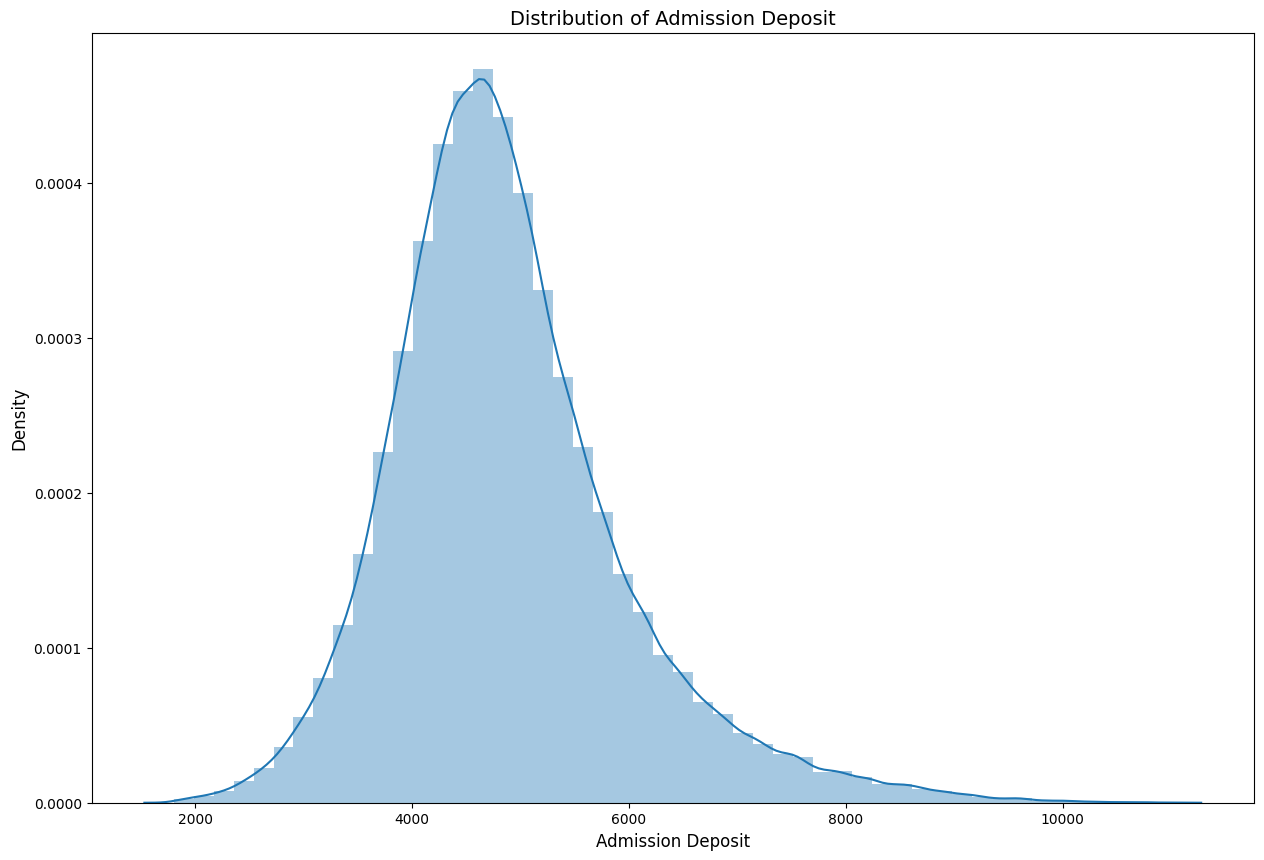

In [ ]:
plt.figure(figsize=(15, 10))

sns.distplot(x_train['Admission_Deposit'])

plt.title('Distribution of Admission Deposit', fontsize=14)
plt.xlabel('Admission Deposit', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.show()

**Distribution of Admission Deposit:**

The plot shows that Admission_Deposit is approximately normally distributed, centered around a mean value, with tails extending toward lower and higher deposits.

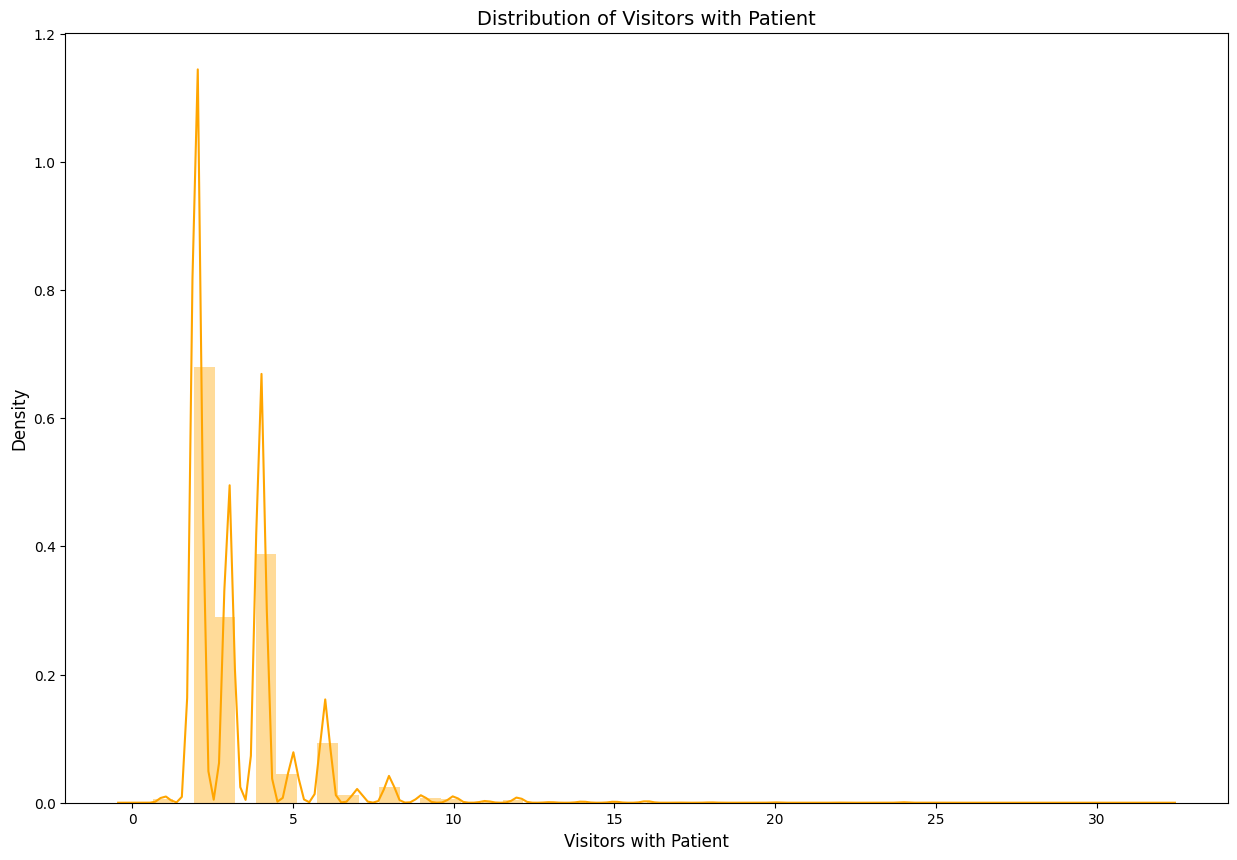

In [ ]:
plt.figure(figsize=(15, 10))

sns.distplot(x_train['Visitors with Patient'], color='orange')

plt.title('Distribution of Visitors with Patient', fontsize=14)
plt.xlabel('Visitors with Patient', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.show()

**Distribution of Visitors with Patient**

The distribution of the number of visitors is highly skewed to the right, indicating that most patients receive a small number of visitors (0 to 4), with fewer cases having a very high number of visitors.

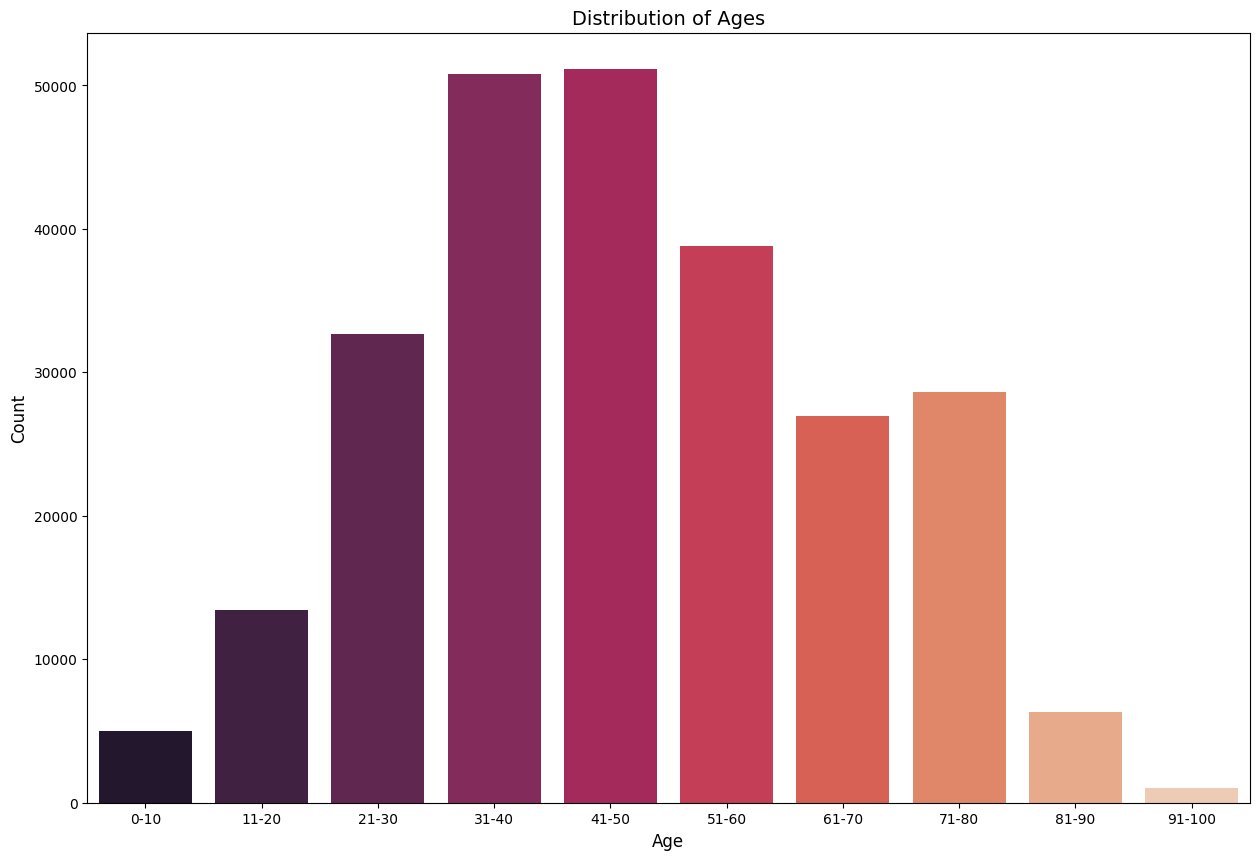

In [ ]:
plt.figure(figsize=(15, 10))

sns.countplot(x=x_train['Age'].sort_values(), data=x_train, palette='rocket')

plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Ages', fontsize=14)

plt.show()

**Distribution of Ages**

The count plot for Age shows that the highest counts belong to the 41-50 and 31-40 age groups, suggesting that the primary demographic is middle-aged, with lower counts observed at the extreme ends of the age spectrum (e.g., 0-10, 81-90).

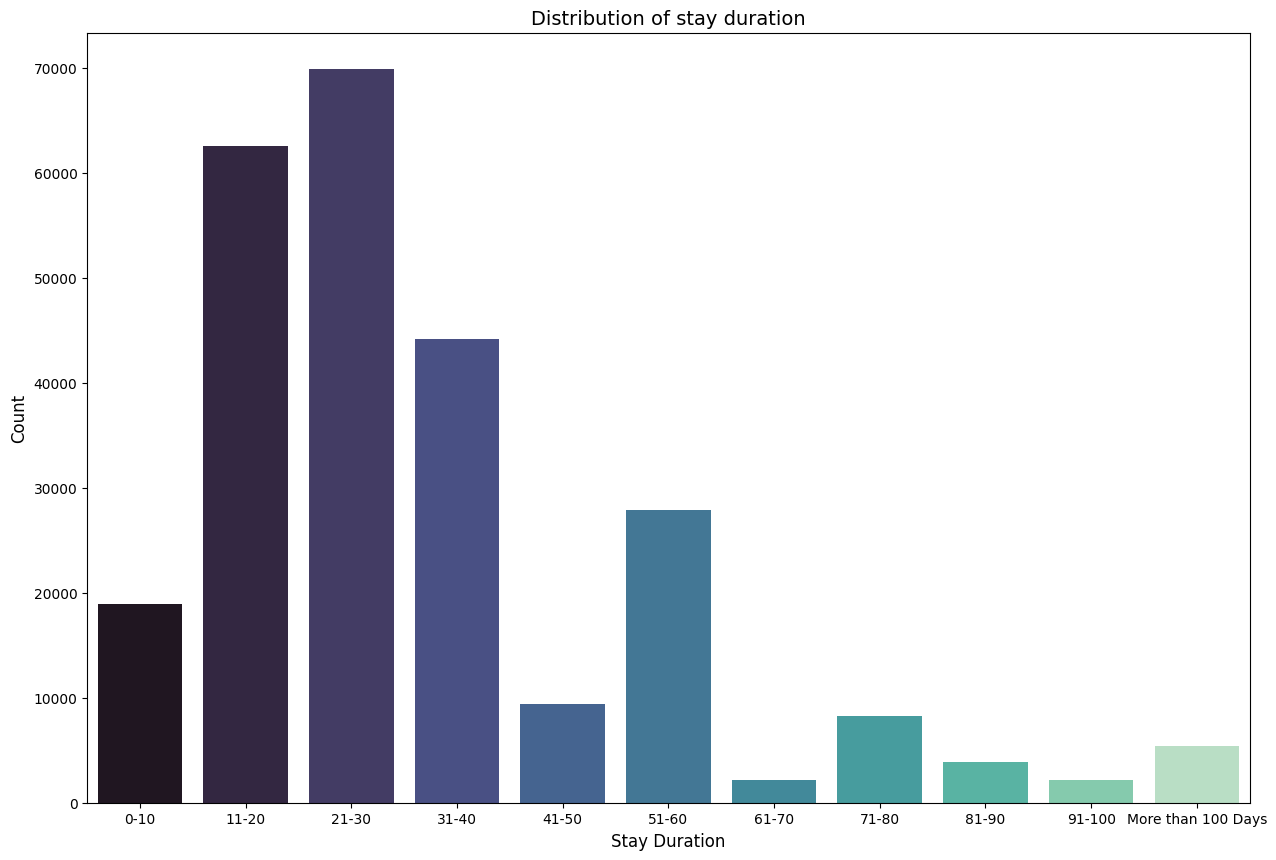

In [ ]:
plt.figure(figsize=(15, 10))

sns.countplot(x=y_train.sort_values(), data=x_train, palette='mako')

plt.xlabel('Stay Duration', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of stay duration', fontsize=14)

plt.show()

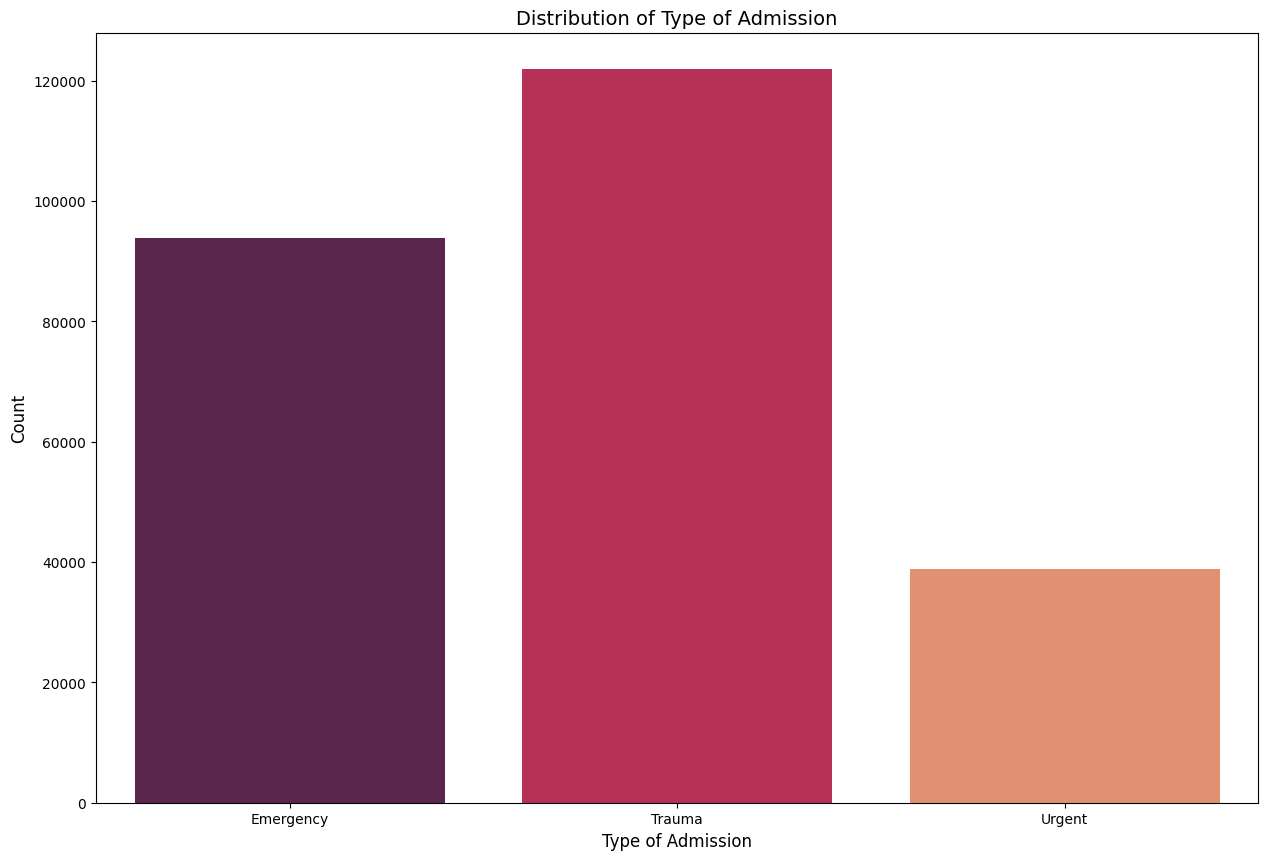

In [ ]:
plt.figure(figsize=(15, 10))

sns.countplot(x=x_train['Type of Admission'].sort_values(), data=x_train, palette='rocket')

plt.xlabel('Type of Admission', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Type of Admission', fontsize=14)

plt.show()

**Distribution of Type of Admission**

The plot indicates that the vast majority of admissions are categorized as Emergency, followed by Trauma, with Urgent admissions being the least frequent type.

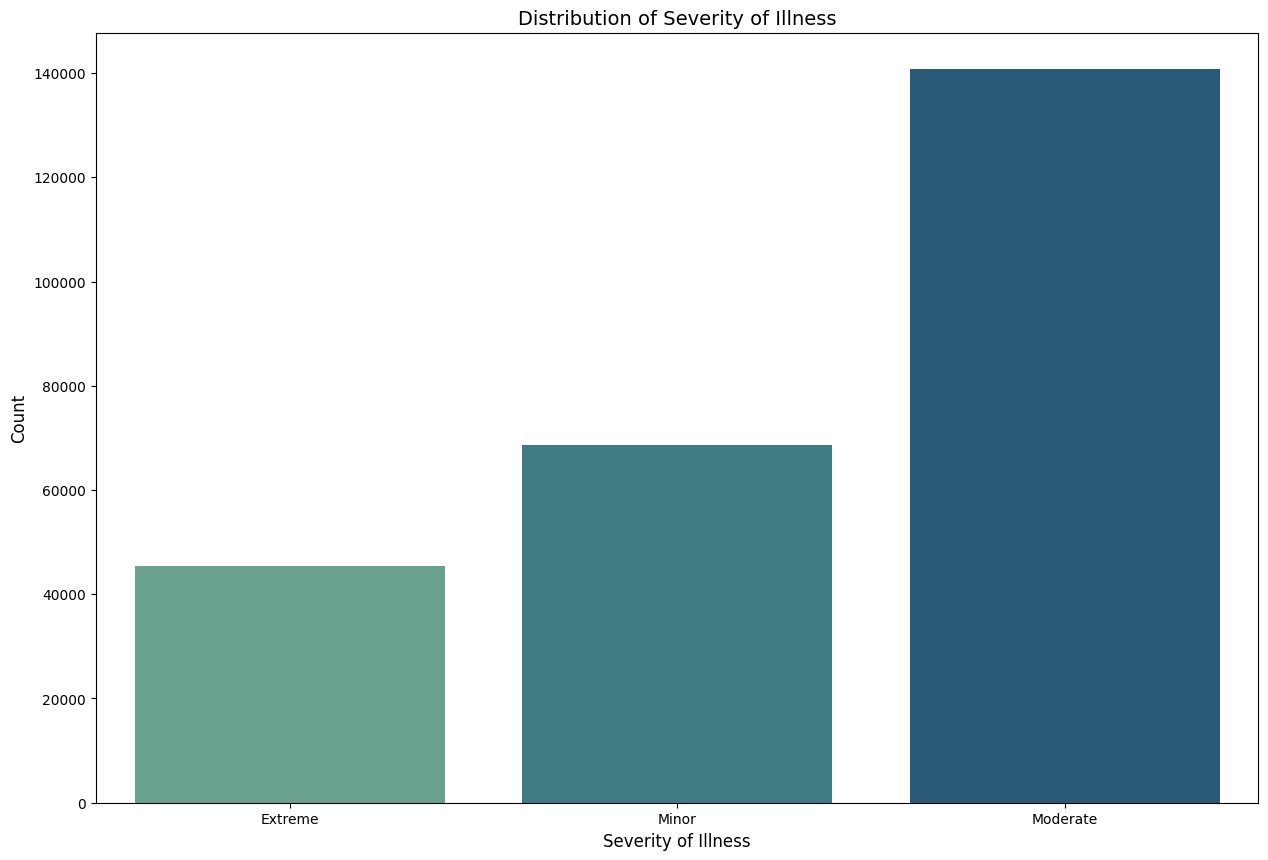

In [ ]:
plt.figure(figsize=(15, 10))

sns.countplot(x=x_train['Severity of Illness'].sort_values(), data=x_train, palette='crest')

plt.xlabel('Severity of Illness', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Severity of Illness', fontsize=14)

plt.show()

**Distribution of Severity of Illness**

The majority of patients are classified under Moderate severity, followed by Minor, with the Extreme severity being the least represented category.

**Correlation Analysis**

Before model training, the relationship between features and the target variable is evaluated using a correlation matrix.

- Ordinal Encoding: Since many features are categorical (nominal and ordinal), they must be converted into numerical representations for correlation calculation. `OrdinalEncoder` is applied to the categorical variables, including the target Stay, mapping their unique string values to sequential integer values.
- Correlation Matrix: The matrix quantifies the linear relationship between all pairs of variables. High absolute correlation values (close to +1 or -1) indicate strong linear dependency, which is important for feature selection and understanding collinearity.

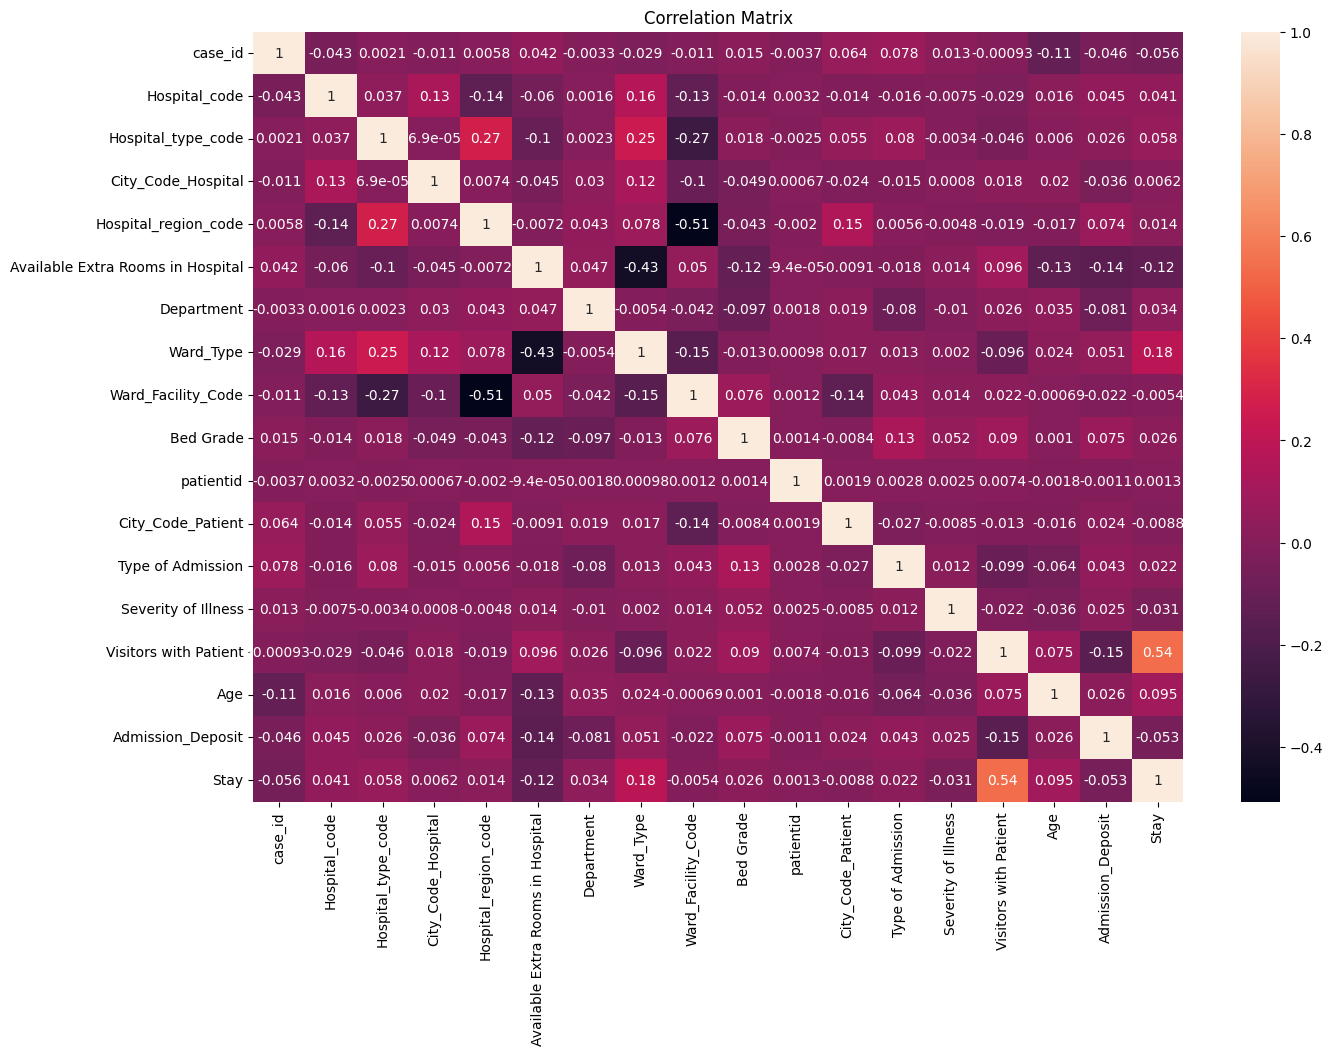

In [16]:
df_corr = pd.concat([x_train, y_train], axis=1) 

categorical_features  = ['Hospital_type_code','Hospital_region_code','Department','Ward_Type','Ward_Facility_Code','Type of Admission',
                         'Severity of Illness','Age','Stay']
ordinal = OrdinalEncoder()
df_corr[categorical_features] = ordinal.fit_transform(df_corr[categorical_features])

correlation_matrix = df_corr.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True,cmap='rocket') 
plt.title('Correlation Matrix')
plt.show()

# Features Engineering

This phase focuses on transforming the raw data into a structure suitable for a Support Vector Machine (or any classification) model. This involves data type correction, feature selection, handling missing values, scaling, encoding, and addressing class imbalance.

**Data Formatting**

The Age feature, which contains categorical ranges, is explicitly converted to string type to prepare it for categorical encoding. Several features deemed non-predictive or redundant are removed to simplify the model and reduce computational complexity. The dropped features include: case_id (a unique identifier), patientid (another unique identifier), City_Code_Hospital, Ward_Facility_Code, and City_Code_Patient. The identification features (case_id and patientid) have high cardinality and no inherent predictive power for Stay.

In [17]:
x_train['Age'] = x_train['Age'].astype(str)
y_train = y_train.astype(str)
x_test['Age'] = x_test['Age'].astype(str)
y_test = y_test.astype(str)

**Noise Features Reduction**

In [ ]:
x_train = x_train.drop(['case_id', 'patientid','City_Code_Hospital','Ward_Facility_Code','City_Code_Patient'], axis=1) 
x_test = x_test.drop(['case_id', 'patientid','City_Code_Hospital','Ward_Facility_Code','City_Code_Patient'], axis=1) 

**Missing Values Imputation, Categorical Features Encoding, Data Normalization**

Data preprocessing is executed using a ColumnTransformer and Pipeline framework. This ensures that different preprocessing steps are applied only to the relevant feature subsets and prevents data leakage by fitting transformers exclusively on the training set.

- Numerical Features: Features like `Hospital_code`, Available Extra Rooms in `Hospital, Bed Grade, Visitors with Patient, and Admission_Deposit` are handled sequentially:
    - Imputation (Missing Values): The `SimpleImputer` with a mean strategy is used to fill missing values in numerical columns (specifically Bed Grade if it were numerical, but the strategy is set for the pipeline).
    - Scaling: The `StandardScaler` is applied to standardize the numerical features. Standardization transforms data such that it has a mean of 0 and a standard deviation of 1. This is critical for distance-based algorithms like SVM, as it prevents features with larger magnitudes from dominating the distance calculations.
- Categorical Features: Features like `Hospital_type_code, Department, Type of Admission, Severity of Illness, and Age` are handled:
    - Imputation (Missing Values): The `SimpleImputer` with a `most_frequent` strategy is used to fill any remaining missing values in categorical columns (e.g., City_Code_Patient which was dropped, but conceptually, this strategy is appropriate for the chosen categorical features).
    - Encoding: The OrdinalEncoder is used to convert categorical string values into numerical integers. This is suitable for features where an inherent order exists (Severity of Illness, Age) or when the resulting number of categories is small. The encoder is configured to handle previously unseen categories in the test set by assigning a known value.

In [ ]:
categorical_features  = ['Hospital_type_code','Hospital_region_code','Department','Ward_Type','Type of Admission','Severity of Illness','Age']

numerical_features = ['Hospital_code','Available Extra Rooms in Hospital','Bed Grade','Visitors with Patient','Admission_Deposit']

def preprocess_data(X_train, X_test, numerical_features, categorical_features):
  """
  Preprocesses the training and test data.

  Args:
      X_train: Training data.
      X_test: Test data.
      numerical_features: List of numerical feature names.
      categorical_features: List of categorical feature names.

  Returns:
      Tuple: Transformed X_train and X_test.
  """

  numerical_pipeline = Pipeline([
      ('imputer', SimpleImputer(strategy='mean')),
      ('scaler', StandardScaler())
  ])

  categorical_pipeline = Pipeline([
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
  ])

  preprocessor = ColumnTransformer([
      ('num', numerical_pipeline, numerical_features),
      ('cat', categorical_pipeline, categorical_features)
  ], remainder='passthrough')

  preprocessor.fit(X_train)

  X_train_processed = preprocessor.transform(X_train)
  X_test_processed = preprocessor.transform(X_test)

  return X_train_processed, X_test_processed


x_train, x_test = preprocess_data(x_train, x_test, numerical_features, categorical_features)

**Oversampling (SMOTE)**

The initial distribution of the target variable Stay shows significant imbalance, with the majority class (21-30 days) accounting for 27.43% and the least common classes (e.g., 61-70 days) making up only 0.86%.
- SMOTE (Synthetic Minority Over-sampling Technique): To counteract this imbalance, the SMOTE algorithm is applied. SMOTE operates by creating synthetic examples for the minority classes. It works by taking samples from the minority class, identifying their nearest neighbors, and generating new data points along the line segments connecting these points. .
- Result Interpretation: After applying SMOTE, the class distribution is perfectly balanced, with all 11 Stay classes now having an equal proportion of 9.09%. This is a necessary step to ensure the classifier learns the patterns of the minority classes effectively, preventing bias towards the majority classes and improving overall classification performance, especially for macro-averaged metrics.

In [20]:
y_train_series = pd.Series(y_train)
print("\nClass Distribution After Undersampling:")
print(y_train_series.value_counts(normalize=True) * 100)


Class Distribution After Undersampling:
Stay
21-30                 27.433955
11-20                 24.564475
31-40                 17.341708
51-60                 10.947988
0-10                   7.424926
41-50                  3.684396
71-80                  3.227870
More than 100 Days     2.116585
81-90                  1.529735
91-100                 0.868695
61-70                  0.859666
Name: proportion, dtype: float64


In [ ]:
sm = SMOTE(random_state=42)

x_resampled, y_resampled = sm.fit_resample(x_train, y_train)
x_train = x_resampled
y_train = y_resampled

y_resampled_series = pd.Series(y_resampled)
print("\nClass Distribution After Undersampling:")
print(y_resampled_series.value_counts(normalize=True) * 100)


Class Distribution After Undersampling:
Stay
21-30                 9.090909
More than 100 Days    9.090909
11-20                 9.090909
61-70                 9.090909
51-60                 9.090909
31-40                 9.090909
0-10                  9.090909
71-80                 9.090909
41-50                 9.090909
91-100                9.090909
81-90                 9.090909
Name: proportion, dtype: float64


**Target Labels Encoding**

The categorical string labels for the target variable Stay are converted to discrete numerical integers using the LabelEncoder. This process is necessary because machine learning models require numerical input for the target variable. The encoded labels are sequential integers from 0 to 10, corresponding to the duration ranges from 0-10 days (Encoded Label: 0) up to More than 100 Days (Encoded Label: 10).

In [ ]:
le = LabelEncoder()

y_train = le.fit_transform(y_train) 
y_test = le.transform(y_test) 

In [ ]:
class_labels = le.classes_
print(class_labels)
for i, label in enumerate(class_labels):
    print(f"Class: {label}, Encoded Label: {i}")

['0-10' '11-20' '21-30' '31-40' '41-50' '51-60' '61-70' '71-80' '81-90'
 '91-100' 'More than 100 Days']
Class: 0-10, Encoded Label: 0
Class: 11-20, Encoded Label: 1
Class: 21-30, Encoded Label: 2
Class: 31-40, Encoded Label: 3
Class: 41-50, Encoded Label: 4
Class: 51-60, Encoded Label: 5
Class: 61-70, Encoded Label: 6
Class: 71-80, Encoded Label: 7
Class: 81-90, Encoded Label: 8
Class: 91-100, Encoded Label: 9
Class: More than 100 Days, Encoded Label: 10


# Model Training and Experiments

This section details the selection, initial evaluation, and hyperparameter tuning of the Ridge Classifier, followed by an interpretation of its performance and decision behavior visualized in two dimensions.

**Ridge Classification in scikit-learn**

The `sklearn.linear_model.RidgeClassifier` is an efficient estimator designed for classification tasks. It adapts the mathematical rigor of Ridge Regression (a continuous prediction model) to handle discrete, multi-class labels, following established scikit-learn conventions.

**1. Core Model and Objective Function**

The Ridge Classifier fundamentally fits a linear model by minimizing a penalized residual sum of squares. It is a linear discriminative model that learns the coefficient vector $\mathbf{w}$ by minimizing the following objective function:

$$J(\mathbf{w}) = \frac{1}{2n_{\text{samples}}} ||X\mathbf{w} - Y||^2_{\text{F}} + \alpha ||\mathbf{w}||^2_{\text{F}}$$

Where:
- $X$ is the matrix of feature data.
- $Y$ is the matrix of target values, encoded to $\{-1, 1\}$ internally for the classification task.
- $\mathbf{w}$ is the matrix of coefficients (one coefficient vector for each class).
- $||\cdot||^2_{\text{F}}$ denotes the Frobenius norm, which is used for matrix quantities.
- $n_{\text{samples}}$ is the number of observations.

**2. L2 Regularization and the $\alpha$ Parameter**

The second term, $\alpha ||\mathbf{w}||^2_{\text{F}}$, represents the $\mathbf{L2}$ penalty, which is the core concept of Ridge models.
- Penalty Function: The penalty is proportional to the square of the magnitude of the coefficient matrix. This method is often called Tikhonov regularization.
- Coefficient Shrinkage: The goal of the penalty is to keep the coefficient values small, preventing the model from becoming overly complex or sensitive to noise in the training data (overfitting).
- Multicollinearity: L2 regularization is highly beneficial when input features are correlated (multicollinear). It handles this issue by averaging the effect across correlated features rather than arbitrarily selecting one and pushing the others toward zero, which leads to greater model stability.
- Regularization Strength ($\alpha$): The hyperparameter $\alpha$ (alpha in scikit-learn) controls the severity of the penalty. A large $\alpha$ results in strong shrinkage (potentially underfitting), while a small $\alpha$ (approaching zero) yields a model close to an unregularized linear model. Optimal performance requires tuning $\alpha$.

**3. Multi-Class Handling: One-vs-Rest (OvR) Strategy**

Since the underlying least-squares solution is naturally suited for continuous outcomes, `RidgeClassifier` employs the One-vs-Rest (OvR) strategy for problems involving $K > 2$ classes (e.g., 11 classes for hospital stay).
- Internal Training: For $K$ target classes, the estimator trains $K$ separate binary Ridge models. The $k$-th model is trained to classify samples belonging to class $k$ as positive ($+1$) and all other $K-1$ samples as negative ($-1$).
- Prediction (`.predict()`): When making a prediction for a new data point $x$, the model evaluates all $K$ decision functions (the output scores from the linear models). The class corresponding to the classifier that yields the highest score is assigned as the final predicted class.
- Decision Function (`.decision_function()`): This method returns the raw output scores from the linear models for each class. These scores represent the distance of the sample from the decision boundary (hyperplane) learned by each binary classifier. Higher scores indicate greater confidence in that class.

**4. Practical Implementation in scikit-learn**

The effectiveness of RidgeClassifier relies on proper data handling, as often emphasized in scikit-learn tutorials:
- Feature Scaling: Scaling features (e.g., using `StandardScaler`) is critical for all L2 regularized models. Without scaling, features with larger initial magnitudes would be disproportionately penalized by the $\alpha$ term, leading to an unfair influence on the model.
- Solver Options: The scikit-learn implementation offers several optimization methods (solver parameter) to fit the model, including 'auto', 'svd', 'cholesky', 'lsqr', 'sag', and 'saga'. The best choice depends on dataset size and density, though 'auto' typically selects an appropriate method. The 'saga' solver is often preferred when large datasets require stochastic gradient descent optimization.
- Class Weighting: The `class_weight='balanced'` parameter can be passed to the estimator. This automatically adjusts the sample weights inversely proportional to the class frequencies, compensating for imbalance in the training data and allowing the model to focus more on predicting minority classes correctly.
- No Probabilities: Unlike logistic regression, the standard `RidgeClassifier` does not directly output calibrated probability estimates (i.e., it lacks a `.predict_proba()` method). Predictions are based solely on the raw decision function scores.

**Initial Model Training (Baseline)**

The baseline performance of the Ridge Classifier is established using K-Fold Cross-Validation (CV). Cross-validation is a technique where the training data is partitioned into $k$ smaller subsets (folds). The model is trained on $k-1$ folds and validated on the remaining fold. This process is repeated $k$ times, and the results are averaged to provide a robust estimate of the model's performance on unseen data. This method helps to identify if the model is overfit or underfit.

In [ ]:
model = RidgeClassifier()

model.fit(x_train, y_train)

cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

print(f"\tK-Fold Cross-Validation Accuracy:", cv_scores)
print('-'*100)
print(f'\tAverage K-Fold Cross-Validation Accuracy: {cv_scores.mean()}')
print('-'*100)

	K-Fold Cross-Validation Accuracy: [0.21892764 0.22171131 0.22289501 0.22158267 0.22221355]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation Accuracy: 0.22146603509010315
----------------------------------------------------------------------------------------------------


**Initial Accuracy**

The K-Fold Cross-Validation accuracy scores consistently range between 0.2189 and 0.2229, resulting in an average CV accuracy of approximately 0.2215. Given that the data was balanced into 11 classes (meaning a random guess would yield approximately $1/11 \approx 0.0909$ accuracy), this initial performance indicates that the model is performing slightly better than chance, but the overall accuracy is low.

**Hyperparameter Optimization (Bayesian Search)**

**Important Hyperparameters for Ridge Classification in scikit-learn**

The behavior and final fit of the RidgeClassifier model are primarily governed by five key hyperparameters that control regularization, the optimization process, and how the model handles unbalanced data.

**1. `alpha` (Regularization Strength)**

The alpha parameter is the most critical hyperparameter for the Ridge Classifier. It is a positive floating-point value that dictates the strength of the L2 penalty added to the loss function. A higher alpha increases the penalty on the magnitude of the model's coefficients, forcing them to shrink closer to zero. This leads to stronger regularization, which generally results in a model with higher bias but lower variance, effectively preventing overfitting and stabilizing the model when features are highly correlated (multicollinearity). Conversely, a lower alpha reduces the penalty, allowing the model to fit the training data more closely, approaching the behavior of a standard unregularized linear classifier. The process of tuning alpha is essential to find the optimal balance between underfitting and overfitting.

**2. `solver` (Optimization Algorithm)**

The solver hyperparameter determines the specific numerical algorithm used by the scikit-learn library to calculate the optimal set of coefficients. Available options include 'auto', 'svd', 'cholesky', 'lsqr', 'sag', and 'saga'. The choice of solver impacts computational efficiency, especially with large datasets:
- `'auto'` attempts to select the best solver based on the data properties.
- `'svd'` (Singular Value Decomposition) is robust for many problems but can be slow.
- `'sag'` (Stochastic Average Gradient) and 'saga' (its modern variant) are often the preferred choices for very large datasets as they are faster, but they require the input data to be properly scaled.

**3. `class_weight` (Class Imbalance Handling)**

The `class_weight` parameter is used to address potential imbalance in the target variable (the classes). It can be set to a custom dictionary of weights or the string 'balanced'. When set to 'balanced', the model automatically computes weights inversely proportional to the frequency of each class in the training data. Assigning higher weights to the minority classes forces the optimization process to focus more heavily on correctly classifying these underrepresented samples. This is a crucial technique for improving the recall and F1-score for minority classes in imbalanced classification problems.

**4. `fit_intercept` (Intercept Calculation)**

The `fit_intercept` hyperparameter is a boolean value (defaulting to True) that specifies whether the linear model should include an independent term, known as the intercept or bias term. When True, the model learns a decision boundary that does not necessarily pass through the origin. It is generally recommended to leave this as True unless the features have been explicitly centered around zero and the model is theoretically expected to pass through the origin.

**5. `max_iter` and `tol` (Convergence Criteria)**

The `max_iter` and `tol` (tolerance) parameters are used together to manage the convergence of iterative solvers ('sag' and 'saga').
- `max_iter` sets an integer limit on the maximum number of iterations (passes over the data) the solver will perform.
- `tol` sets the convergence criterion: the solver stops if the change in the loss function between successive iterations is less than this threshold. A smaller tol demands a more precise solution and may require a higher `max_iter` setting.

**Bayesian Search for Hyperparameter Optimization (BayesSearchCV)**

Bayesian Search, realized in scikit-learn through the `BayesSearchCV` class (originating from the scikit-optimize or skopt library), is a sophisticated and efficient alternative to exhaustive grid search or randomized search for finding the optimal hyperparameter settings.

Bayesian optimization is a sequential strategy for minimizing an expensive, black-box function, which, in the context of machine learning, is the process of model training and cross-validation performance evaluation.
- Surrogate Function (Probabilistic Model): Instead of evaluating every combination or randomly sampling points, Bayesian Search constructs a probabilistic model, typically a Gaussian Process, to serve as a Surrogate Function. This function models the relationship between the hyperparameter space and the expected model performance (e.g., accuracy). This surrogate model is significantly cheaper to evaluate than training the actual machine learning model.
- Acquisition Function: An Acquisition Function is then used to decide which hyperparameter setting to sample and evaluate next. This function intelligently guides the search by balancing two critical strategies:
- Exploitation: Sampling points close to the current best-observed hyperparameter setting to refine the optimum.
- Exploration: Sampling points in areas of the search space that have high uncertainty in the surrogate model, ensuring the global optimum is not missed.
Common acquisition functions include 'Expected Improvement (EI)' and 'Lower Confidence Bound (LCB)'.

This informed, sequential sampling approach allows Bayesian Search to typically find near-optimal hyperparameters in far fewer overall model evaluations compared to the brute-force or uniform sampling strategies of traditional search methods, making it highly efficient for time-consuming models.

**Key Hyperparameters for BayesSearchCV**

The `BayesSearchCV` class manages the core Bayesian optimization process through specific parameters:

1. `search_spaces`
This is the mandatory definition of the hyperparameter ranges to be explored. Unlike other search methods that accept lists of values or simple distributions, `BayesSearchCV` requires defining the space using skopt.space objects (e.g., Real for floats, Integer for integers, and Categorical for discrete choices). This allows the algorithm to understand the boundaries and distributions of the parameters for effective modeling by the surrogate function.

2. `n_iter`
This parameter specifies the total budget for the search—the maximum number of hyperparameter settings that will be sampled and evaluated using cross-validation. This number dictates the duration of the search; fewer iterations are typically required than in Randomized Search due to the informed sampling strategy.

3. `n_initial_points`
This integer defines the number of initial parameter settings that must be sampled randomly before the informed, Bayesian optimization process begins. The Bayesian search requires these initial, randomly sampled data points to build the first version of the probabilistic surrogate function. A sufficient number of initial points is necessary to broadly characterize the search space before starting the targeted search.

4. `acq_func`
This parameter specifies the acquisition function strategy to be used. Common settings are 'EI' (Expected Improvement, the default and a popular choice) or 'LCB' (Lower Confidence Bound). The choice of acquisition function influences the balance between exploration (testing new areas) and exploitation (refining known good areas) during the search.

5. `n_points`
This optional parameter specifies the number of hyperparameter settings to evaluate in parallel at each iteration. When used in conjunction with the n_jobs parameter, it helps manage the concurrent execution of cross-validation fits, which can significantly reduce the wall-clock time required for the search.

6. `random_state`
Setting the `random_state` (an integer seed) is crucial for ensuring the reproducibility of the search. This seed fixes the sequence of random numbers used, particularly for generating the initial random samples (n_initial_points) and controlling the randomness inherent in the optimization process.

**Implementation**

To improve the model's generalization capability, Bayesian Optimization is used to efficiently search the hyperparameter space. Unlike grid search, which exhaustively checks all combinations, or random search, which samples randomly, Bayesian Optimization constructs a probabilistic model of the function mapping hyperparameters to the objective score (accuracy in this case). This allows it to intelligently select the next set of hyperparameters to evaluate, focusing on regions likely to yield the best results.

The key hyperparameters tuned were:

- `alpha`: The regularization strength for the L2 penalty.
- `class_weight`: Set to balanced to automatically adjust weights inversely proportional to class frequencies, compensating for the residual difficulty posed by the imbalanced nature of the target even after SMOTE.
- `solver`: The algorithm used for optimization (saga was selected as the best solver).

In [ ]:
model = RidgeClassifier()

param_space = {
    'alpha': Real(1e-6, 100.0, prior='log-uniform'),
    'fit_intercept': Categorical([True, False]),
    'max_iter': Integer(100, 1000, prior='uniform'),
    'tol': Real(1e-6, 1e-2, prior='log-uniform'),
    'solver': Categorical(['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga']),
    'class_weight': Categorical([None, 'balanced'])
}

bayes_search = BayesSearchCV(
    estimator=model,
    search_spaces=param_space,
    n_iter=5,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

bayes_search.fit(x_train, y_train)

print("Best hyperparameters:", bayes_search.best_params_)

best_model = bayes_search.best_estimator_

cv_scores = cross_val_score(best_model, x_train, y_train, cv=5, scoring='accuracy')

print(f"\tK-Fold Cross-Validation Accuracy:", cv_scores)
print('-'*100)
print(f'\tAverage K-Fold Cross-Validation Accuracy: {cv_scores.mean()}')
print('-'*100)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best hyperparameters: OrderedDict([('alpha', 5.001575677983704), ('class_weight', 'balanced'), ('fit_intercept', True), ('max_iter', 956), ('solver', 'saga'), ('tol', 1.7752182884113584e-06)])
	K-Fold Cross-Validation Accuracy: [0.21892113 0.22169179 0.22290152 0.22156966 0.22220054]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation Accuracy: 0.22145692960209534
----------------------------------------------------------------------------------------------------


**Optimal Hyperparameters**

The search identified the best configuration, including an `alpha` value of 5.0016 and the use of the `balanced` class weight.

**Tuned Accuracy**

The average accuracy after optimization, evaluated using Stratified K-Fold (which ensures each fold has the same proportion of target classes as the entire dataset), remained around 0.2215. This indicates that while the Bayesian search found the mathematically optimal parameter combination, it did not significantly improve the predictive power beyond the baseline model for the chosen architecture (Ridge Classifier).

In [ ]:
print("Ridge Regression Best hyperparameters:", bayes_search.best_params_)

best_model_ridge = bayes_search.best_estimator_

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_ridge = cross_val_score(best_model_ridge, x_train, y_train, cv=stratified_kfold, scoring='accuracy')

print(f"\tRidge K-Fold Cross-Validation Accuracy:", cv_scores_ridge)
print('-' * 100)
print(f'\tAverage Ridge K-Fold Cross-Validation Accuracy: {cv_scores_ridge.mean()}')
print('-' * 100)

Ridge Regression Best hyperparameters: OrderedDict([('alpha', 5.001575677983704), ('class_weight', 'balanced'), ('fit_intercept', True), ('max_iter', 956), ('solver', 'saga'), ('tol', 1.7752182884113584e-06)])
	Ridge K-Fold Cross-Validation Accuracy: [0.22189341 0.22043654 0.2197016  0.22337125 0.22184933]
----------------------------------------------------------------------------------------------------
	Average Ridge K-Fold Cross-Validation Accuracy: 0.22145042759288353
----------------------------------------------------------------------------------------------------


**Decision Boundary (2D Feature Space)**

The plot visualizes the model's decision boundaries using only two features: Available Extra Rooms in Hospital and Visitors with Patient.

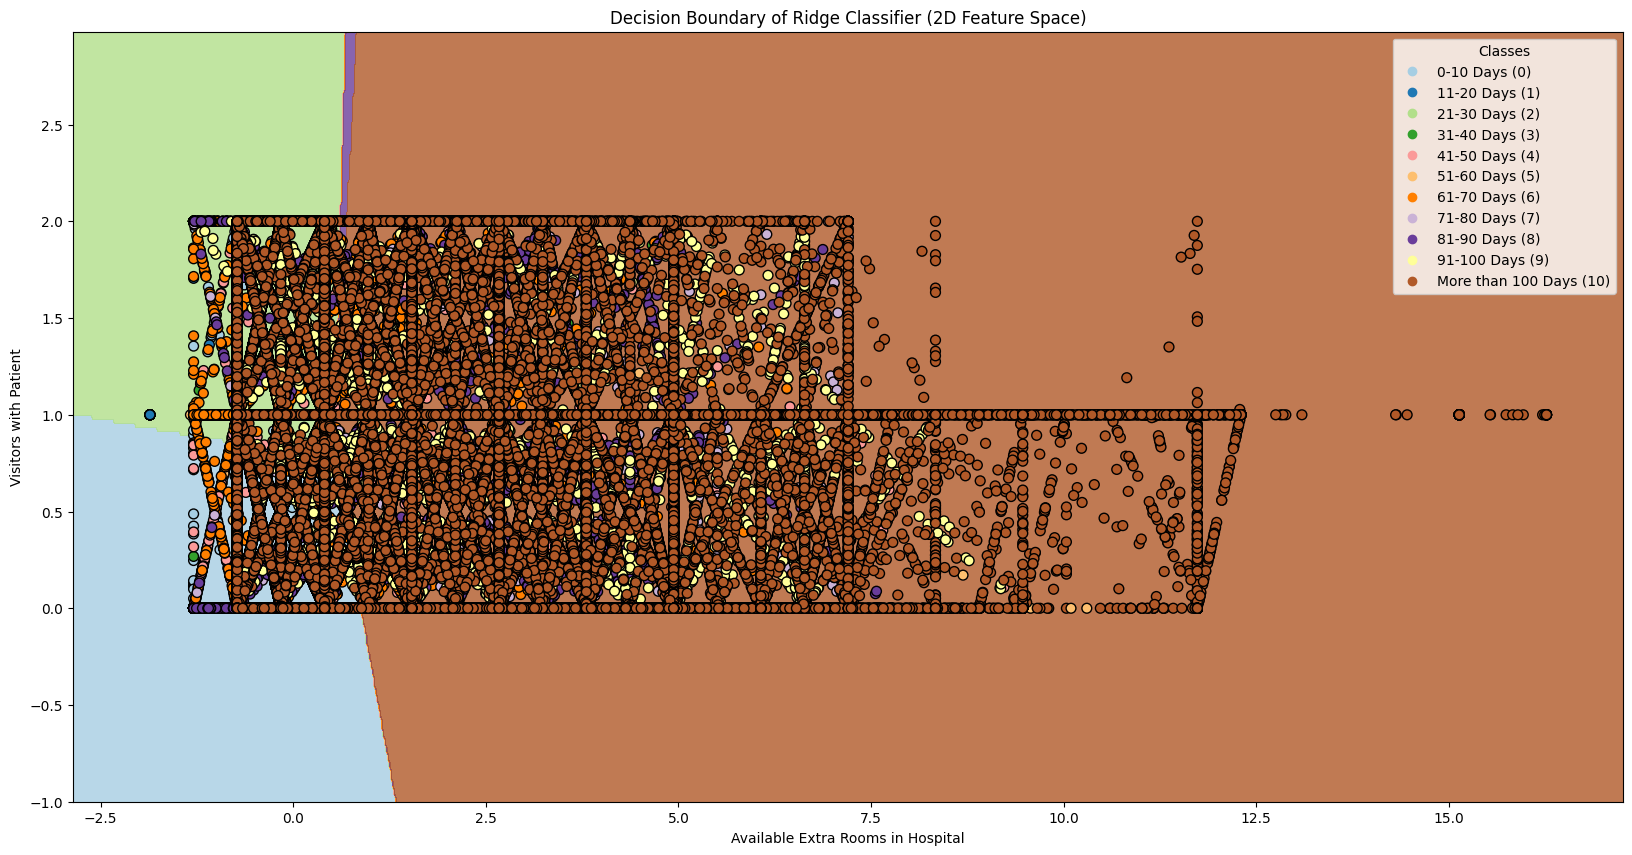

In [ ]:
class_labels = [
    "0-10 Days (0)", "11-20 Days (1)", "21-30 Days (2)", "31-40 Days (3)",
    "41-50 Days (4)", "51-60 Days (5)", "61-70 Days (6)", "71-80 Days (7)",
    "81-90 Days (8)", "91-100 Days (9)", "More than 100 Days (10)"
]

if not isinstance(x_train, pd.DataFrame):
    columns = [
        'Hospital_code', 'Hospital_type_code', 
        'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department',
        'Ward_Type', 'Bed Grade',
        'Type of Admission', 'Severity of Illness',
        'Visitors with Patient', 'Age', 'Admission_Deposit'
    ]
    x_train = pd.DataFrame(x_train, columns=columns)

if not isinstance(x_test, pd.DataFrame):
    columns = [
        'Hospital_code', 'Hospital_type_code', 
        'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department',
        'Ward_Type', 'Bed Grade',
        'Type of Admission', 'Severity of Illness',
        'Visitors with Patient', 'Age', 'Admission_Deposit'
    ]
    x_test = pd.DataFrame(x_test, columns=columns)

feature1 = 'Available Extra Rooms in Hospital'
feature2 = 'Visitors with Patient'

if feature1 not in x_train.columns or feature2 not in x_train.columns:
    raise ValueError(f"One or both of the features '{feature1}' and '{feature2}' are not in x_train. Please select valid features.")

X_2d = x_train[[feature1, feature2]]
X_test_2d = x_test[[feature1, feature2]]

alpha = getattr(best_model_ridge, 'alpha', 1.0)
model_2d = RidgeClassifier(alpha=alpha)

model_2d.fit(X_2d, y_train)

h = 0.02
x_min, x_max = X_2d[feature1].min() - 1, X_2d[feature1].max() + 1
y_min, y_max = X_2d[feature2].min() - 1, X_2d[feature2].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(20, 10))
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

scatter = plt.scatter(X_2d[feature1], X_2d[feature2], c=y_train, cmap=plt.cm.Paired, edgecolors='k', s=50)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Decision Boundary of Ridge Classifier (2D Feature Space)')

plt.legend(handles=scatter.legend_elements()[0], labels=class_labels, title="Classes", loc="best")
plt.show()

**Interpretation of Visualization Results**

- Linear Separability: The Ridge Classifier, being a linear model, attempts to separate the 11 classes using straight or slightly curved lines (hyperplanes in higher dimensions).
- Boundary Complexity: The resulting decision boundary is highly fragmented and complex, particularly in the central region where most data points are concentrated.
- Inter-Class Overlap: The significant overlap of the data points from different classes within the same color regions (predicted classes) confirms the low accuracy observed in the quantitative results. The model struggles to define clear, distinct regions for each of the 11 Stay duration classes based on these two features alone.

**Decision Functions (1D Feature Space)**

These plots simplify the classification task to a binary problem: distinguishing between the shortest stay (0-10 Days, Class 0) and the longest stay (More than 100 Days, Class 10).

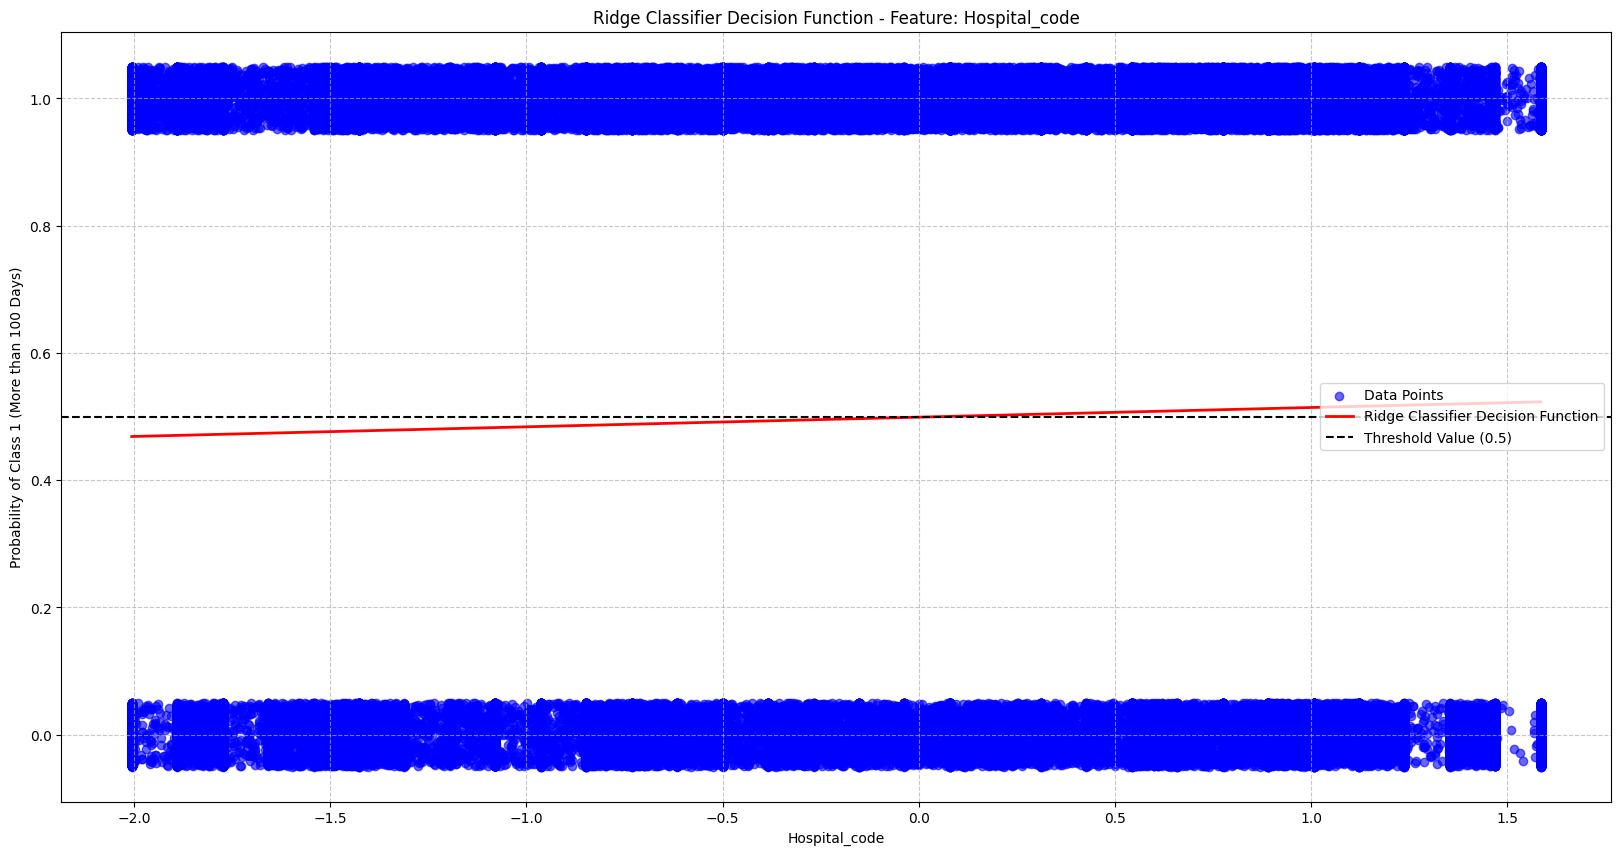

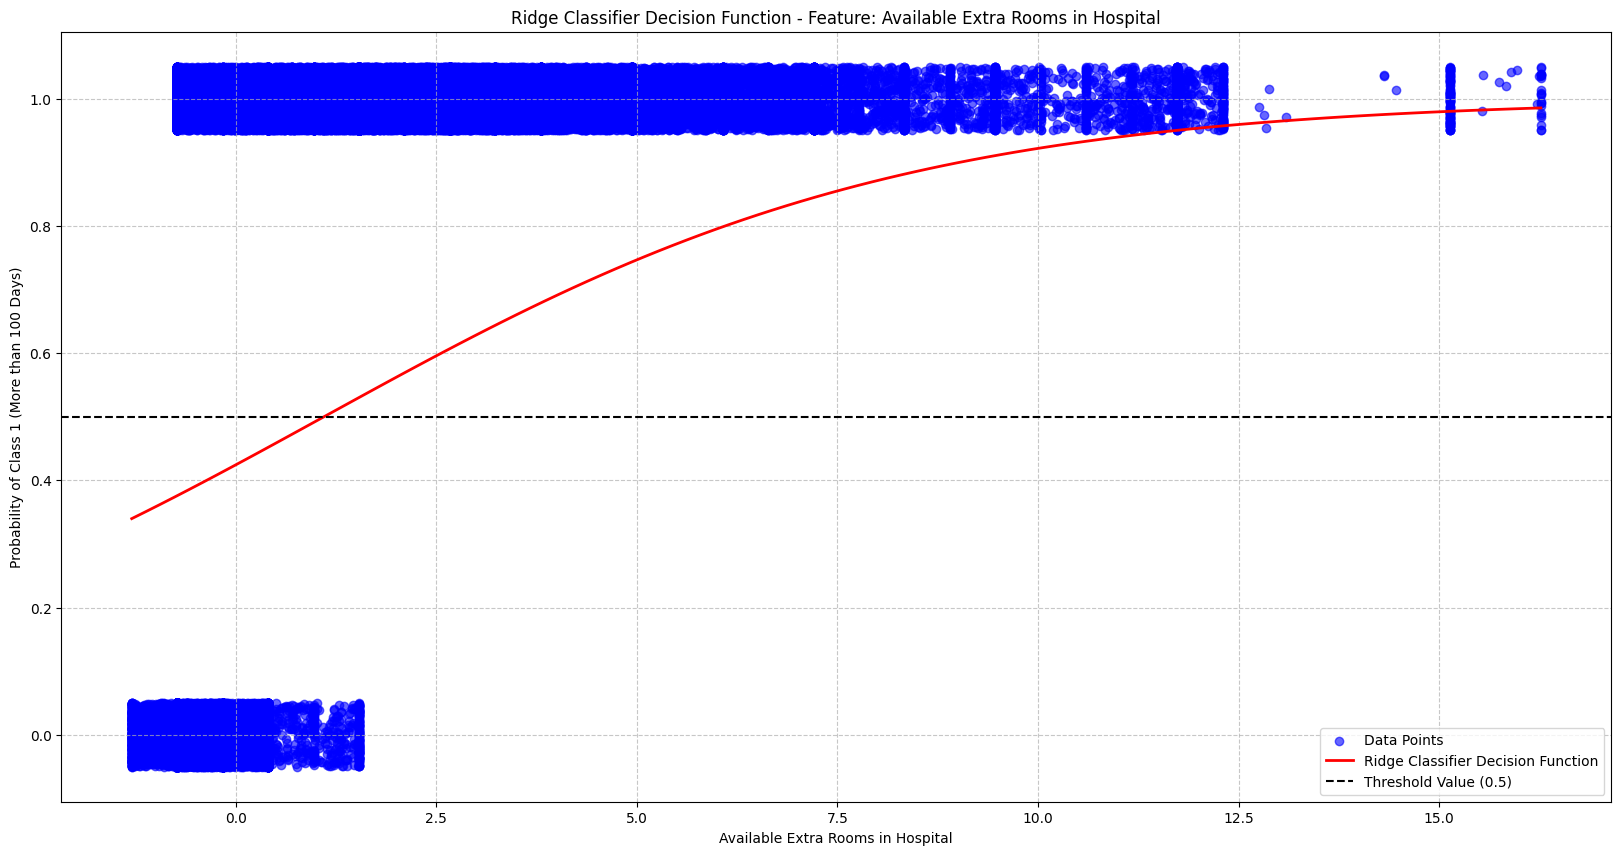

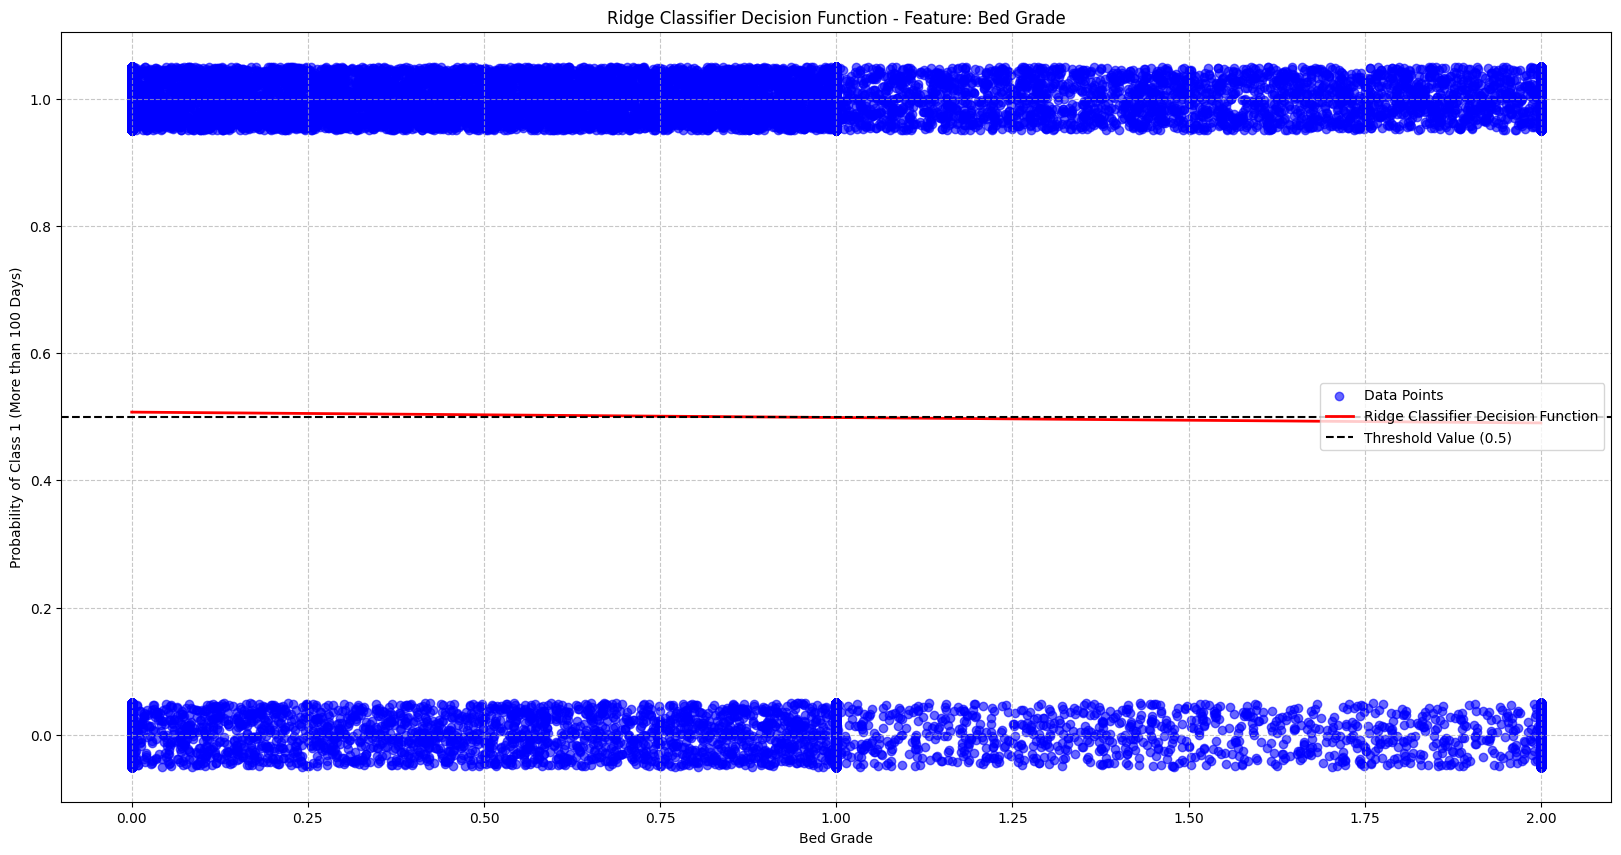

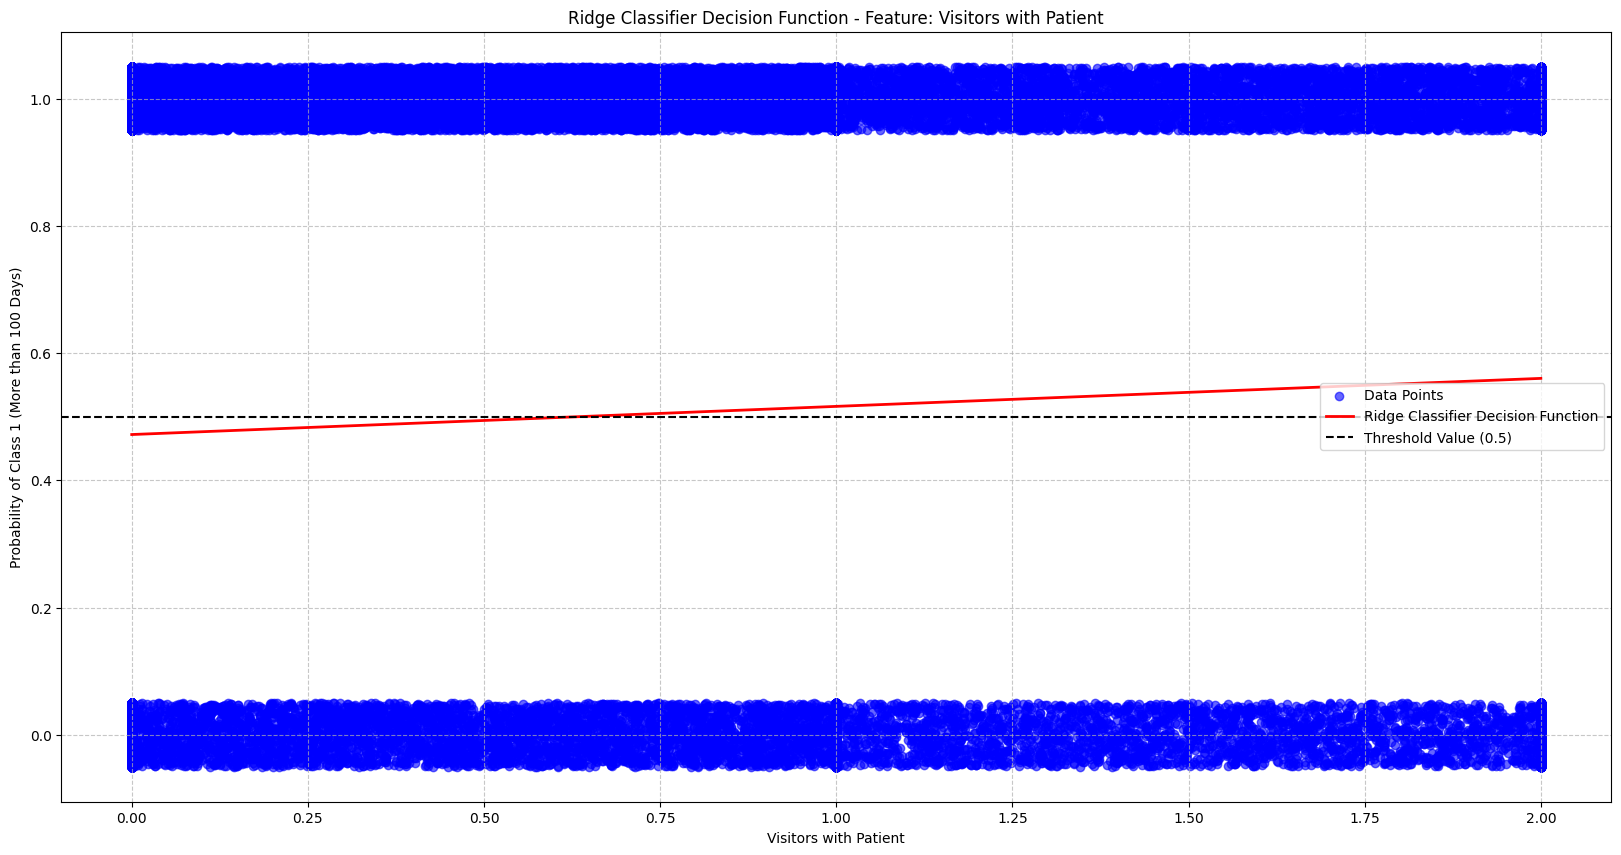

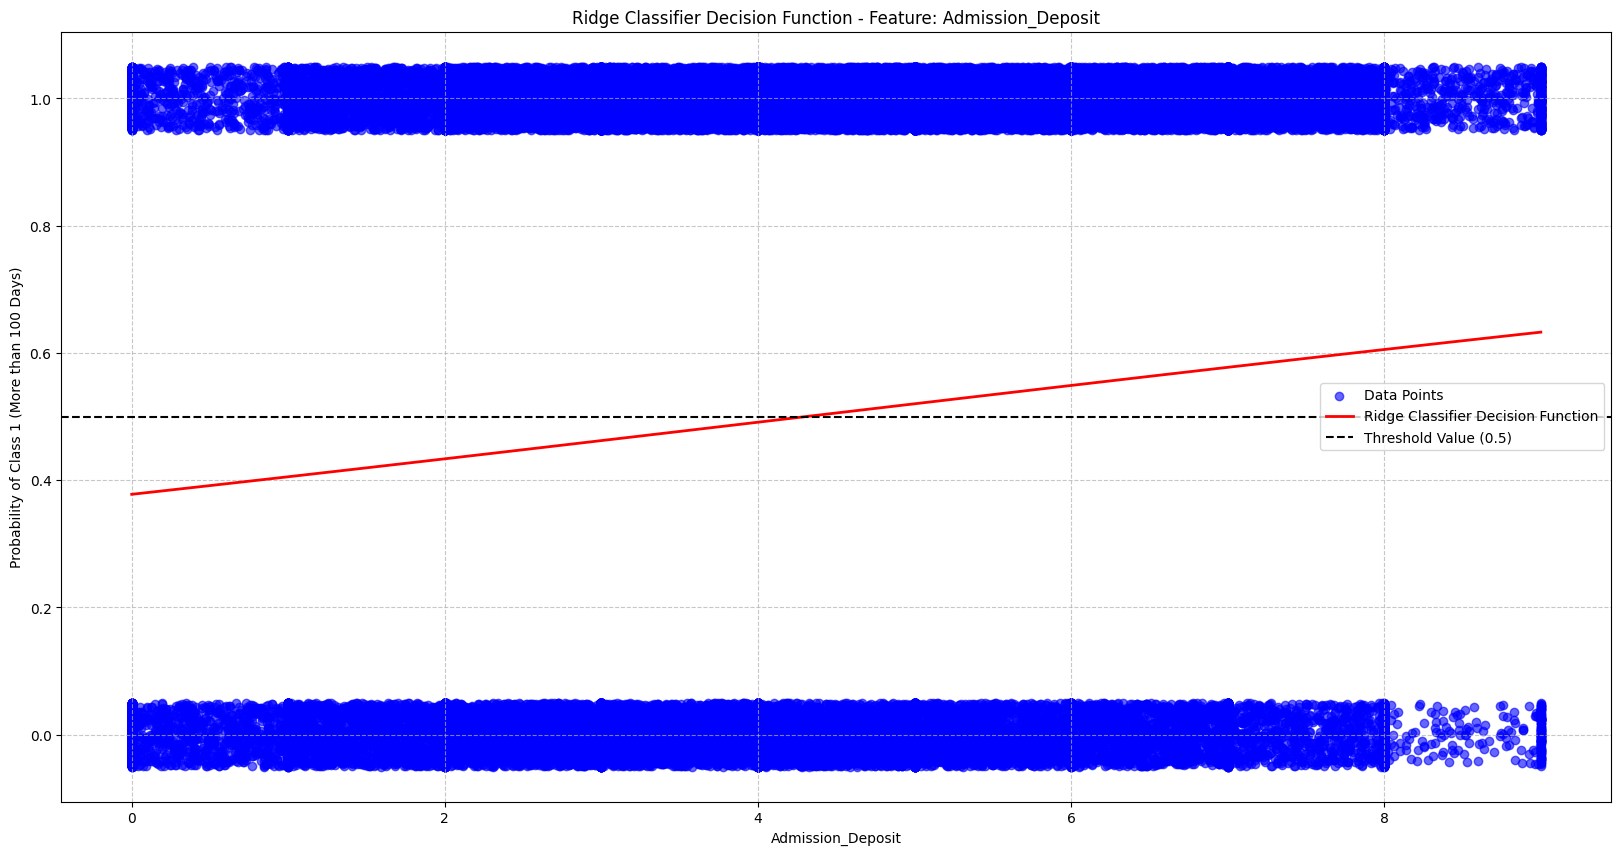

In [ ]:
class_labels = [
    "0-10 Days (0)", "11-20 Days (1)", "21-30 Days (2)", "31-40 Days (3)",
    "41-50 Days (4)", "51-60 Days (5)", "61-70 Days (6)", "71-80 Days (7)",
    "81-90 Days (8)", "91-100 Days (9)", "More than 100 Days (10)"
]

if not isinstance(x_train, pd.DataFrame):
    columns = [
        'Hospital_code', 'Hospital_type_code', 
        'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department',
        'Ward_Type', 'Bed Grade',
        'Type of Admission', 'Severity of Illness',
        'Visitors with Patient', 'Age', 'Admission_Deposit'
    ]
    x_train = pd.DataFrame(x_train, columns=columns)

if not isinstance(x_test, pd.DataFrame):
    columns = [
        'Hospital_code', 'Hospital_type_code', 
        'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department',
        'Ward_Type', 'Bed Grade',
        'Type of Admission', 'Severity of Illness',
        'Visitors with Patient', 'Age', 'Admission_Deposit'
    ]
    x_test = pd.DataFrame(x_test, columns=columns)

if not isinstance(y_train, pd.Series):
    y_train = pd.Series(y_train, name='Target')

binary_classes = [0, 10]
mask = y_train.isin(binary_classes)
X_binary = x_train[mask]
y_binary = y_train[mask]

y_binary = (y_binary == 10).astype(int)

features = [
    'Hospital_code', 'Available Extra Rooms in Hospital', 'Bed Grade',
    'Visitors with Patient', 'Admission_Deposit'
]

alpha = getattr(best_model_ridge, 'alpha', 1.0)
model_1d = RidgeClassifier(alpha=alpha)

for feature in features:
    if feature not in X_binary.columns:
        raise ValueError(f"Feature '{feature}' is not in x_train. Please select a valid feature.")

    X_1d = X_binary[[feature]]

    model_1d.fit(X_1d, y_binary)

    x_range = np.linspace(X_1d[feature].min(), X_1d[feature].max(), 100).reshape(-1, 1)
    decision_scores = model_1d.decision_function(x_range)

    probabilities = 1 / (1 + np.exp(-decision_scores))

    plt.figure(figsize=(20, 10))
    plt.scatter(X_1d[feature], y_binary + np.random.uniform(-0.05, 0.05, size=len(y_binary)), 
                color='blue', label='Data Points', alpha=0.6)
    plt.plot(x_range, probabilities, color='red', label='Ridge Classifier Decision Function', linewidth=2)
    plt.axhline(y=0.5, color='black', linestyle='--', label='Threshold Value (0.5)')

    plt.xlabel(feature)
    plt.ylabel('Probability of Class 1 (More than 100 Days)')
    plt.title(f'Ridge Classifier Decision Function - Feature: {feature}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

**Interpretation of Visualization Results**

The red line represents the decision function output, which approximates the probability of the patient staying 'More than 100 Days' (Class 10).

- Admission Deposit: The decision function shows a slight positive trend as Admission_Deposit increases. However, the probability line hovers mostly below the 0.5 threshold, suggesting that the model is generally conservative in predicting the longer stay, regardless of the deposit amount. Only for deposits above approximately 4.5 does the probability exceed 0.5, but the data points are scattered widely. .
- Available Extra Rooms in Hospital: This feature shows the strongest relationship among the numerical features. As the number of available rooms increases, the approximated probability of a long stay rises significantly, crossing the 0.5 threshold around 5-10 rooms. This suggests that the availability of extra rooms is a relevant indicator for predicting longer hospital stays in the binary context. .
- Hospital Code, Bed Grade, Visitors with Patient: For these features, the decision function line remains relatively flat and close to the 0.5 threshold across the entire feature range. This indicates that these individual features have a weak linear correlation with the probability of a very long stay (More than 100 Days). The model relies minimally on the linear relationship with these inputs when making its binary prediction. 

**Conclusion of Modeling Interpretation**

The Ridge Classifier exhibits poor predictive performance (22.15% accuracy) on this multi-class problem, even after extensive data balancing and hyperparameter tuning. The visualizations confirm that a simple linear model cannot effectively separate the 11 complex target classes, indicating that non-linear or more complex feature interactions are likely necessary to achieve substantial performance improvement.

# Model Evaluation

This section presents the performance metrics of the best-tuned Ridge Classifier model on the unseen test dataset and interprets the results using a confusion matrix and decision visualization plots.

**Classification Report**

Model evaluation is crucial for assessing how well a trained model generalizes to new, unobserved data. Several metrics are employed to provide a comprehensive view of performance, especially in multi-class classification problems like predicting hospitalization stay duration.

In [ ]:
y_pred = best_model_ridge.predict(x_test)  

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy: 0.226
Precision: 0.150
Recall: 0.212
F1-score: 0.130


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.56      0.23      4689
           1       0.36      0.23      0.28     15561
           2       0.42      0.36      0.39     17603
           3       0.21      0.00      0.01     10981
           4       0.07      0.09      0.08      2357
           5       0.17      0.05      0.08      7128
           6       0.01      0.07      0.02       554
           7       0.06      0.01      0.02      2031
           8       0.03      0.09      0.05       941
           9       0.04      0.13      0.06       552
          10       0.13      0.73      0.22      1291

    accuracy                           0.23     63688
   macro avg       0.15      0.21      0.13     63688
weighted avg       0.28      0.23      0.21     63688



**Result Interpretation**

- Accuracy: Represents the proportion of total correct predictions. The model achieved a test set accuracy of 0.226. Given 11 target classes, this value is significantly higher than the baseline random chance (approximately $0.091$ or $1/11$). However, the overall performance remains low, suggesting that a simple linear model is insufficient to capture the complexity of the data relationships.
- Precision: Measures the accuracy of positive predictions (i.e., of all instances predicted as Class X, what fraction truly belonged to Class X). The macro-averaged precision is 0.150, indicating substantial misclassification across different classes.
- Recall: Measures the ability of the model to find all the positive samples (i.e., of all true instances of Class X, what fraction was correctly predicted as Class X). The macro-averaged recall is 0.212.
- F1-Score: The harmonic mean of precision and recall, providing a balanced measure that penalizes models with extremely uneven precision and recall. The macro-averaged F1-score is 0.130, highlighting the weak performance in simultaneously achieving high precision and recall across all classes.

These low macro-averaged scores emphasize the challenge posed by the multi-class prediction task and the inherent limitations of a linear classification approach for this dataset.

**Confusion Matrix**

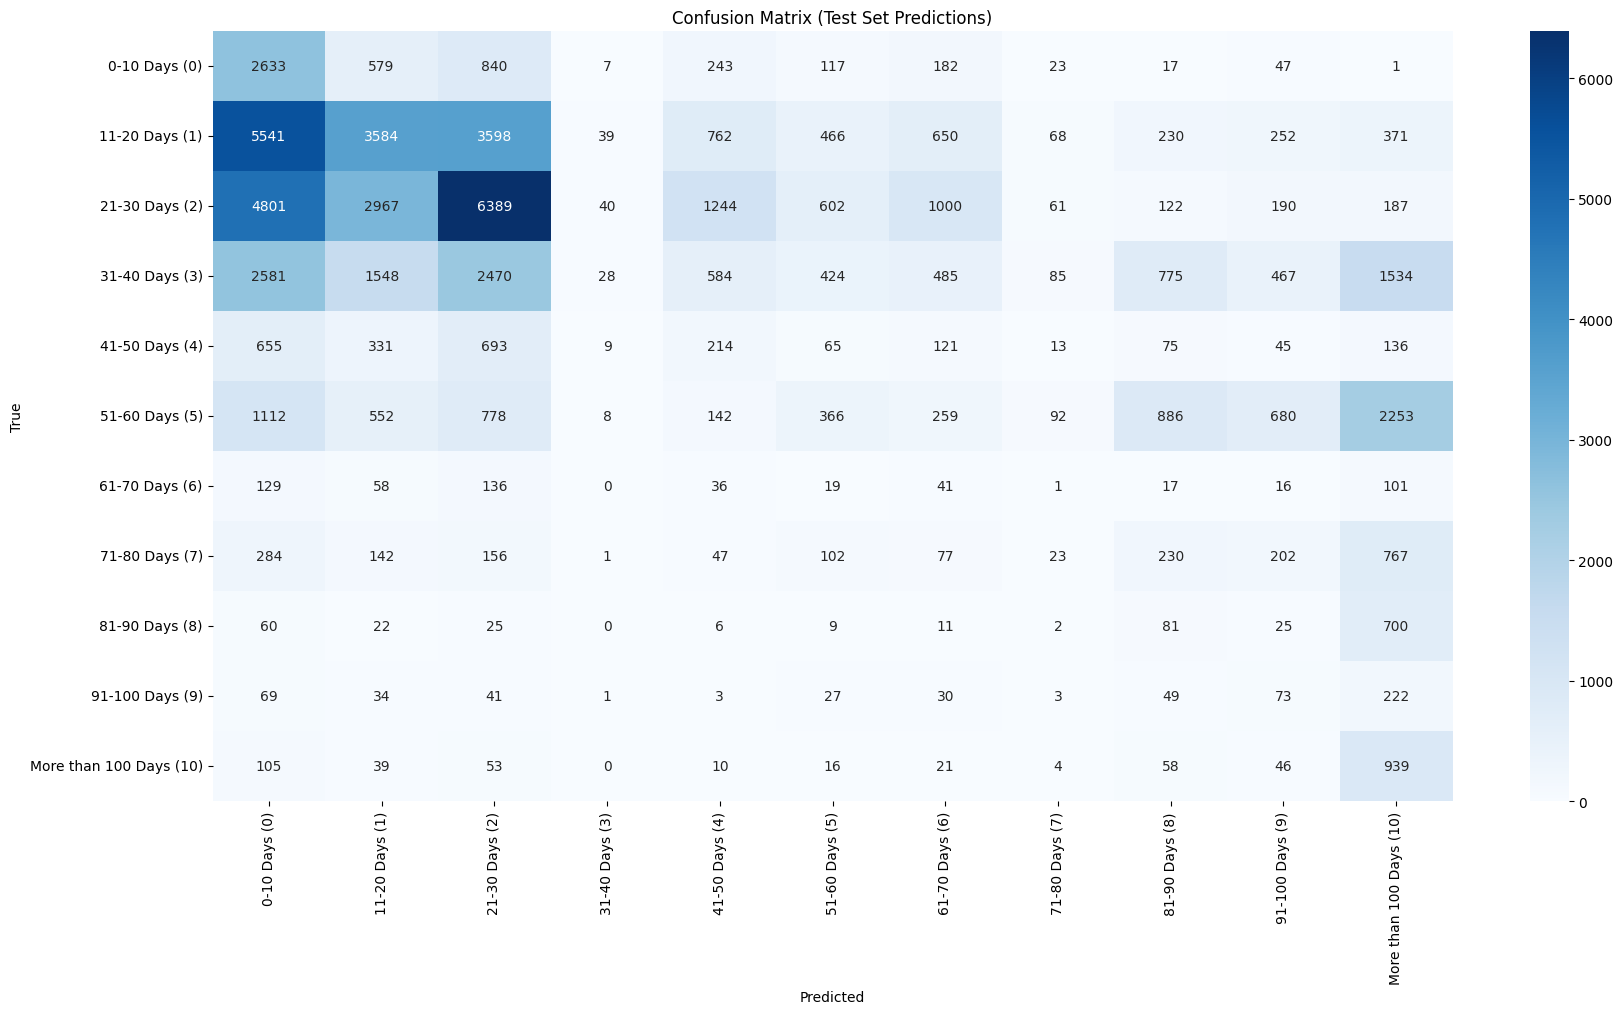

In [ ]:
class_labels = [
    "0-10 Days (0)", "11-20 Days (1)", "21-30 Days (2)", "31-40 Days (3)",
    "41-50 Days (4)", "51-60 Days (5)", "61-70 Days (6)", "71-80 Days (7)",
    "81-90 Days (8)", "91-100 Days (9)", "More than 100 Days (10)"
]

plt.figure(figsize=(20, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set Predictions)')
plt.show()

**Confusion Matrix Interpretation**

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each of the 11 stay duration classes, allowing for the identification of specific misclassification patterns.

- Diagonal Dominance: The matrix lacks strong diagonal dominance, confirming the low overall accuracy. Correct predictions (the diagonal elements) are relatively few compared to off-diagonal errors.
- Prediction Skew: The model exhibits a pronounced bias toward predicting a few specific classes:
    - Class 2 (21-30 Days): This class has the highest volume of true positives (6389), making it the most successfully predicted single class.
    - Class 1 (11-20 Days): Shows moderate predictive success (3584 true positives).
- Misclassification Patterns (Over-prediction): The model frequently misclassifies other classes into these highly represented duration bins. For example:
    - Class 0 (0-10 Days) is correctly predicted 2633 times but is incorrectly predicted as Class 1 (5541) and Class 2 (4801) more often.
- Misclassification Patterns (Under-prediction): The model severely struggles with longer stay durations:
    - Classes 3 through 9 (31-100 Days): These medium-to-long stay classes have very low recall values (e.g., Class 3 has $0.00$ recall). The true instances of these classes are almost always incorrectly predicted as another, more common class (like Class 10 or Class 2).
    - Class 10 (More than 100 Days): While having the highest individual recall (0.73), this appears artificially high because the confusion matrix shows that Class 10 is the target of many incorrect predictions from other classes. For example, thousands of patients whose true stay was Class 4, 5, 6, 7, 8, or 9 are incorrectly predicted to be Class 10. The high recall suggests the model defaults to this class frequently when unsure of the correct, less frequent outcome.

In summary, the model primarily acts as a poorly performing binary classifier, often distinguishing only between the shortest stays and the very long stays, while significantly blurring the lines between all intermediate durations.

**Decision Boundary (2D Feature Space)**

The plot displays the decision boundary on the test data using the features Available Extra Rooms in Hospital and Visitors with Patient.
- Boundary Instability: The visualization shows a fragmented, complex, and oscillatory boundary structure, particularly in the dense data region where Available Extra Rooms is between $0$ and $7$ and Visitors with Patient is between $0$ and $2$. This irregular pattern suggests model over-fitting or severe instability due to the high dimensionality being projected onto only two features.
- Dominant Region: The vast majority of the feature space, especially for Available Extra Rooms greater than $1$ or $2$, is predicted to be Class 10 (More than 100 Days). This visually reinforces the bias observed in the confusion matrix, where the model preferentially predicts the longest stay duration when it encounters data points with a wide range of feature values.

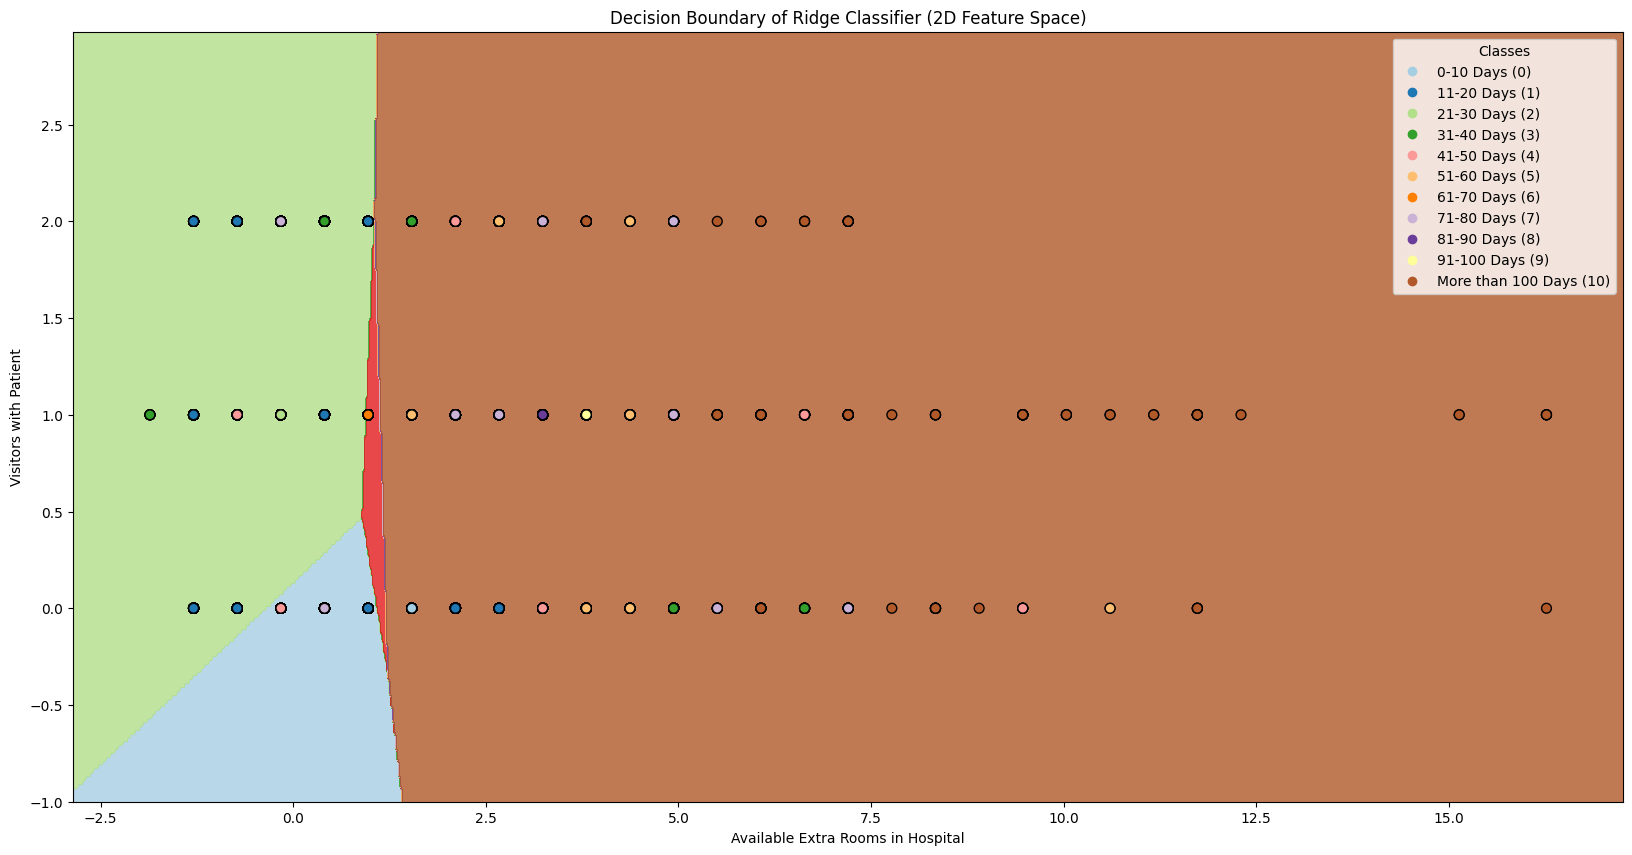

In [ ]:
class_labels = [
    "0-10 Days (0)", "11-20 Days (1)", "21-30 Days (2)", "31-40 Days (3)",
    "41-50 Days (4)", "51-60 Days (5)", "61-70 Days (6)", "71-80 Days (7)",
    "81-90 Days (8)", "91-100 Days (9)", "More than 100 Days (10)"
]

if not isinstance(x_train, pd.DataFrame):
    columns = [
        'Hospital_code', 'Hospital_type_code', 
        'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department',
        'Ward_Type', 'Bed Grade',
        'Type of Admission', 'Severity of Illness',
        'Visitors with Patient', 'Age', 'Admission_Deposit'
    ]
    x_train = pd.DataFrame(x_train, columns=columns)

if not isinstance(x_test, pd.DataFrame):
    columns = [
        'Hospital_code', 'Hospital_type_code', 
        'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department',
        'Ward_Type', 'Bed Grade',
        'Type of Admission', 'Severity of Illness',
        'Visitors with Patient', 'Age', 'Admission_Deposit'
    ]
    x_test = pd.DataFrame(x_test, columns=columns)

feature1 = 'Available Extra Rooms in Hospital'
feature2 = 'Visitors with Patient'

if feature1 not in x_train.columns or feature2 not in x_train.columns:
    raise ValueError(f"One or both of the features '{feature1}' and '{feature2}' are not in x_train. Please select valid features.")

X_2d = x_test[[feature1, feature2]]
X_test_2d = x_test[[feature1, feature2]]

alpha = getattr(best_model_ridge, 'alpha', 1.0)
model_2d = RidgeClassifier(alpha=alpha)

model_2d.fit(X_2d, y_test)

h = 0.02
x_min, x_max = X_2d[feature1].min() - 1, X_2d[feature1].max() + 1
y_min, y_max = X_2d[feature2].min() - 1, X_2d[feature2].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(20, 10))
plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

scatter = plt.scatter(X_2d[feature1], X_2d[feature2], c=y_test, cmap=plt.cm.Paired, edgecolors='k', s=50)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Decision Boundary of Ridge Classifier (2D Feature Space)')

plt.legend(handles=scatter.legend_elements()[0], labels=class_labels, title="Classes", loc="best")
plt.show()

**Decision Function (1D Feature Space)**

The sigmoid-like curves, derived from the Ridge Classifier's decision function, approximate the probability of Class 10 (long stay) versus Class 0 (short stay) based on single features in the test set.
- Available Extra Rooms in Hospital: The probability curve rises sharply, crossing the $0.5$ decision threshold around $2.5$ available rooms. This indicates that for the test data, a higher number of available rooms strongly correlates with a higher predicted probability of a long stay.
- Admission Deposit: The probability curve shows a gradual, linear increase, crossing the $0.5$ threshold at an Admission_Deposit value of approximately $4.0$. While it suggests a weak positive relationship, the probability remains low even at high deposit amounts, highlighting the feature's limited predictive strength for this binary outcome.
- Hospital Code, Bed Grade, Visitors with Patient: For these features, the decision function remains almost perfectly flat, hovering near or slightly below the $0.5$ threshold across all feature values. This confirms that, in isolation, these three features contribute negligibly in a linear fashion to the model's decision between a very short or very long hospital stay.

The visualizations collectively demonstrate that the model’s linear structure is inadequate for the multi-class prediction task. While Available Extra Rooms in Hospital shows some discriminating power, the model exhibits instability and a strong bias toward predicting the longest stay duration due to the complexity and imbalance of the target variable.

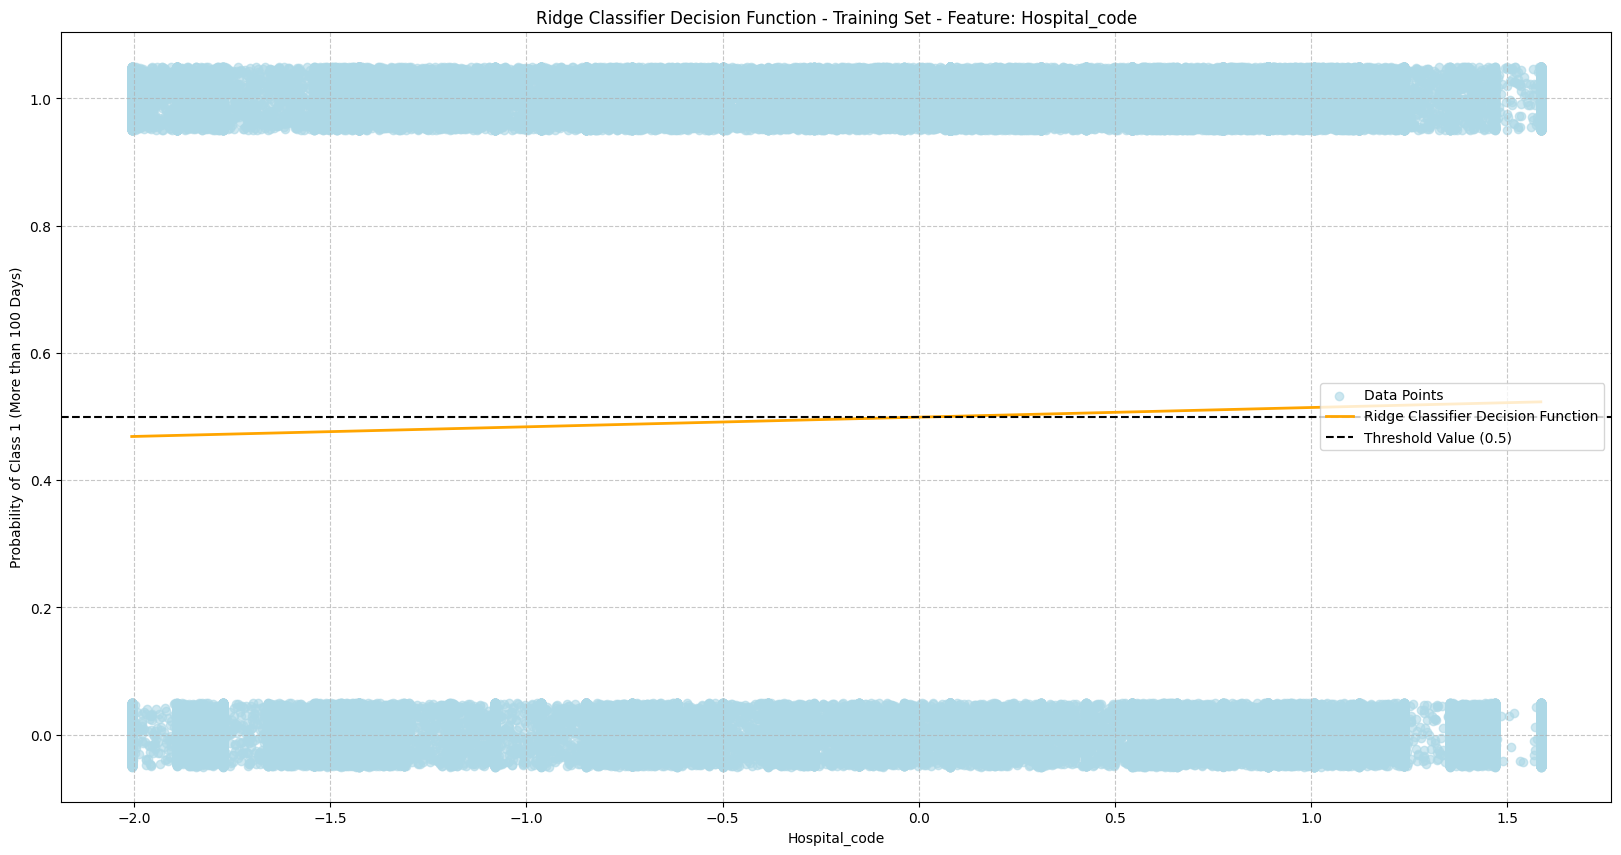

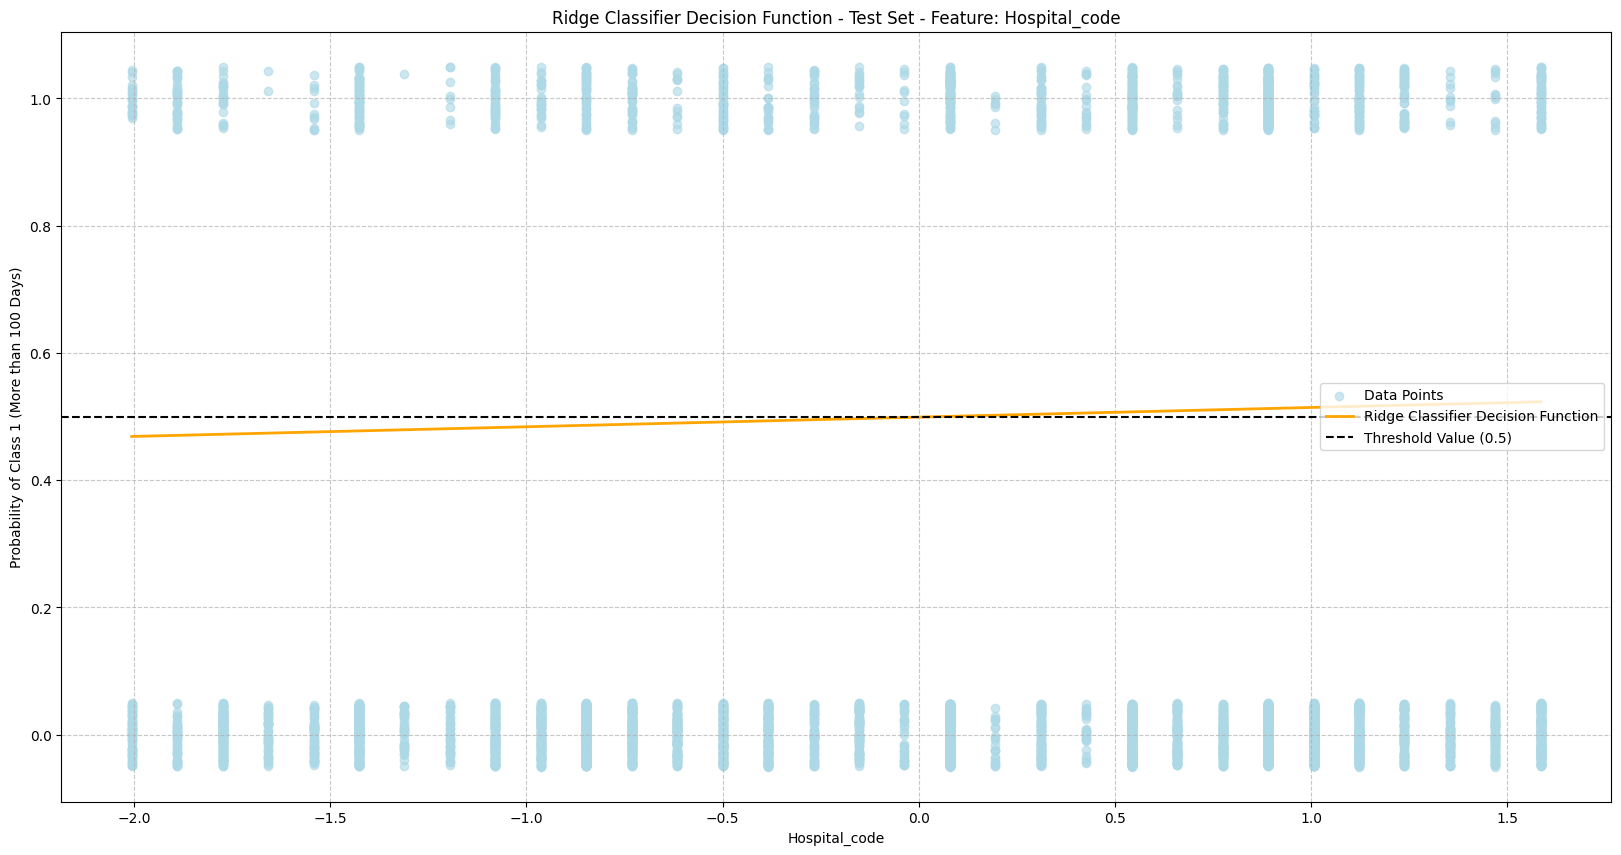

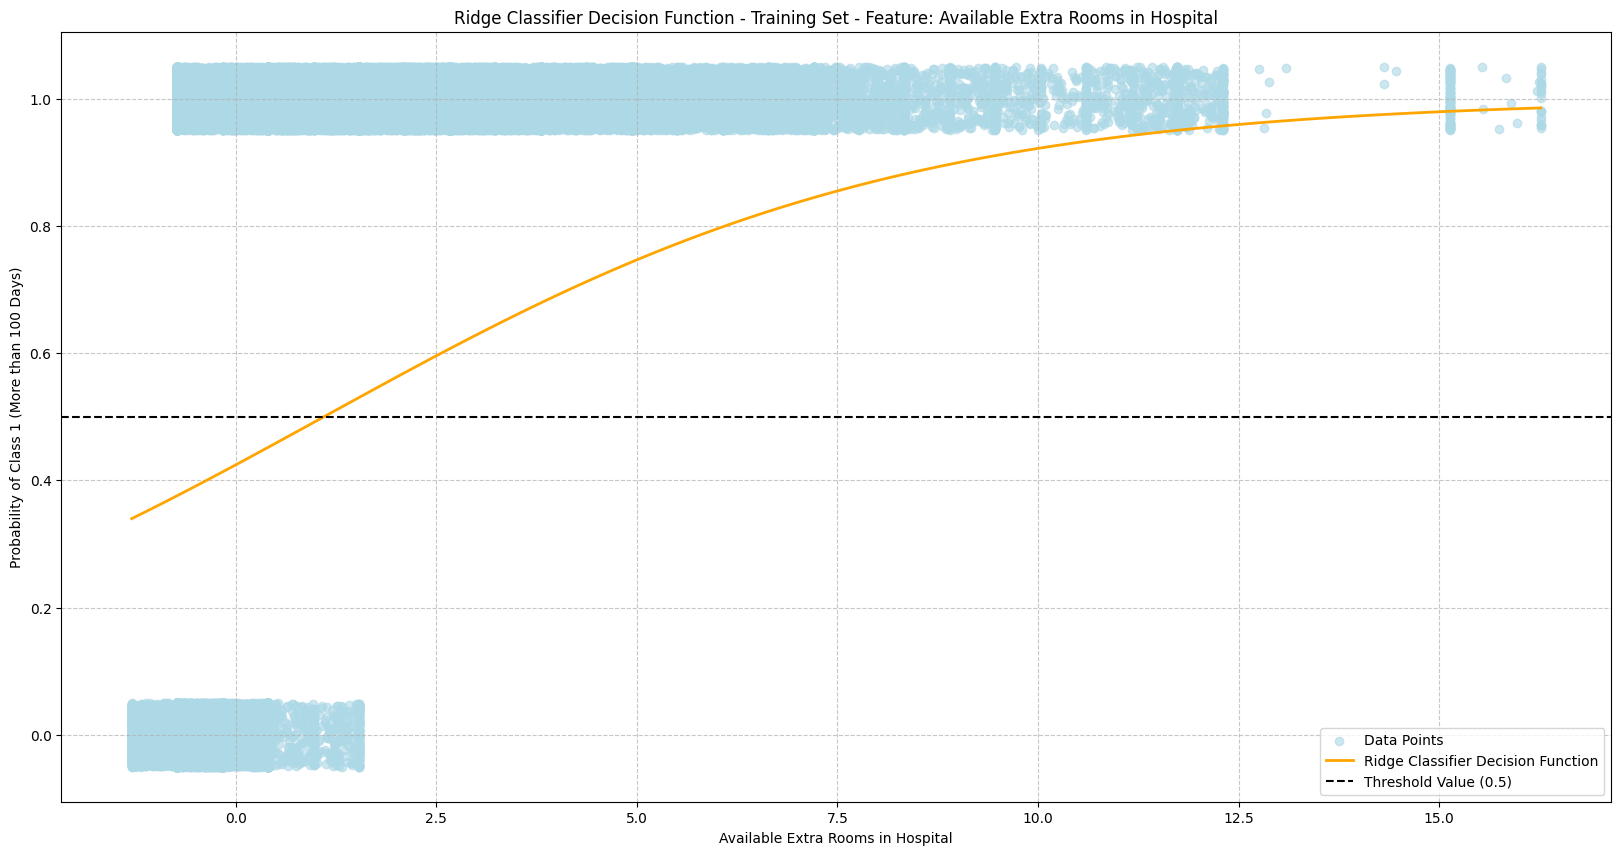

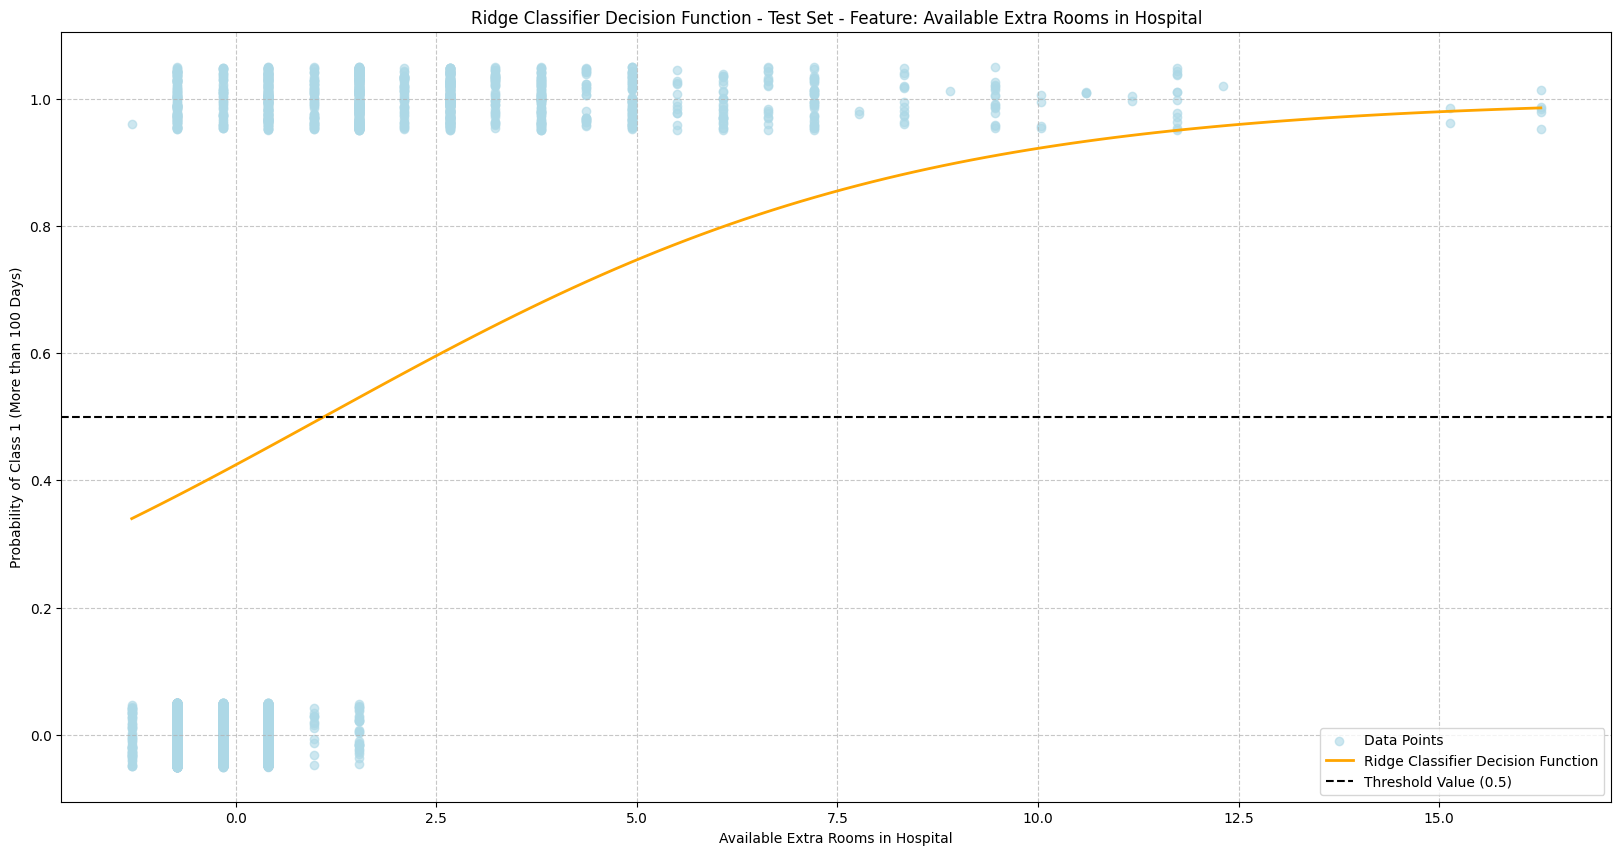

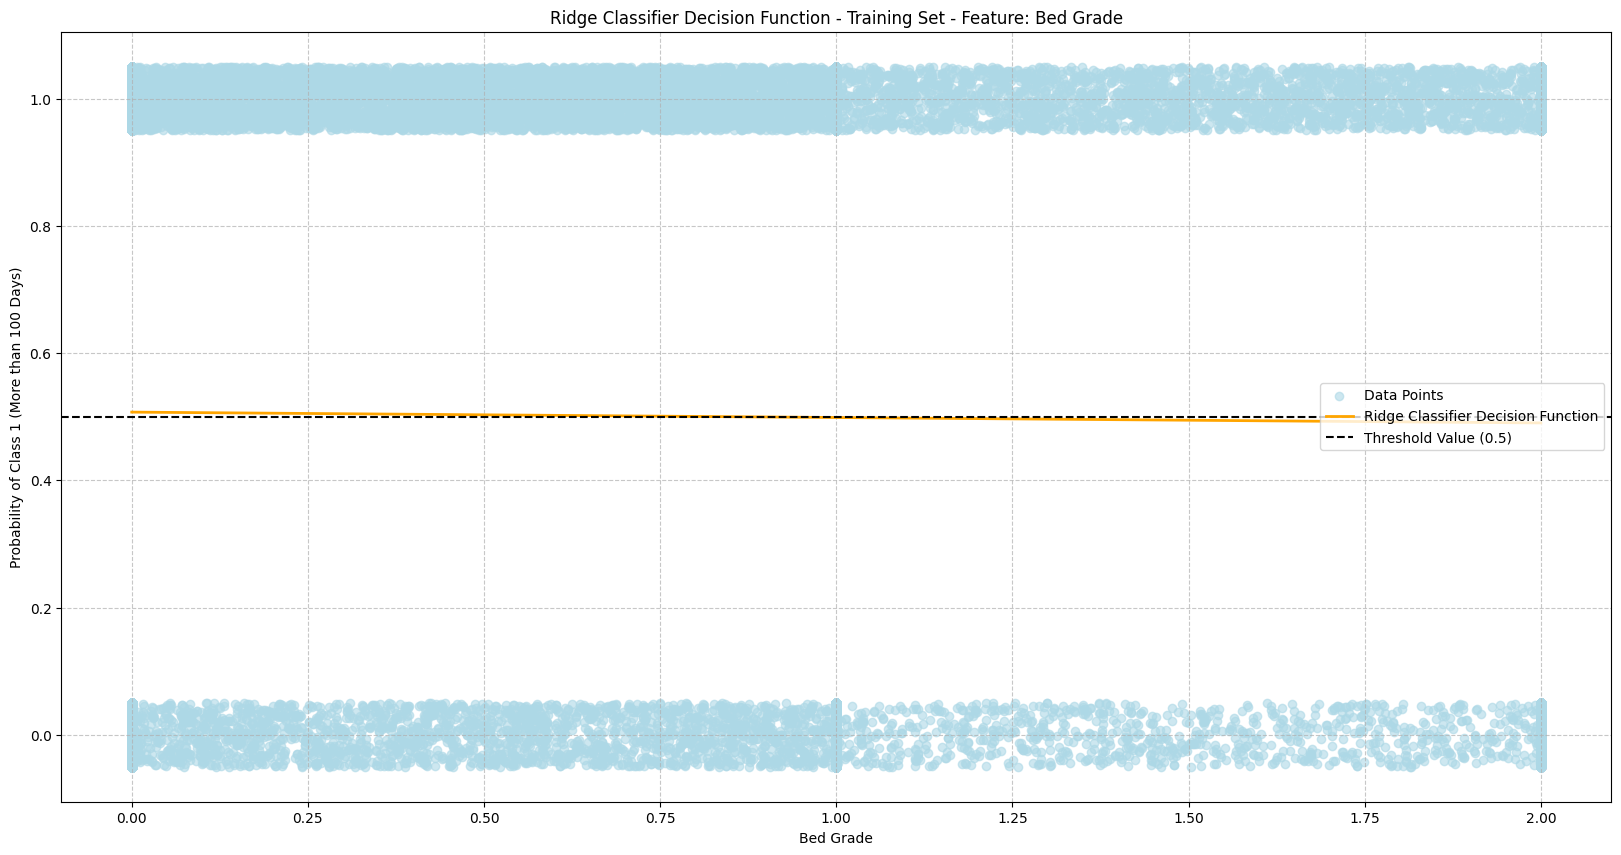

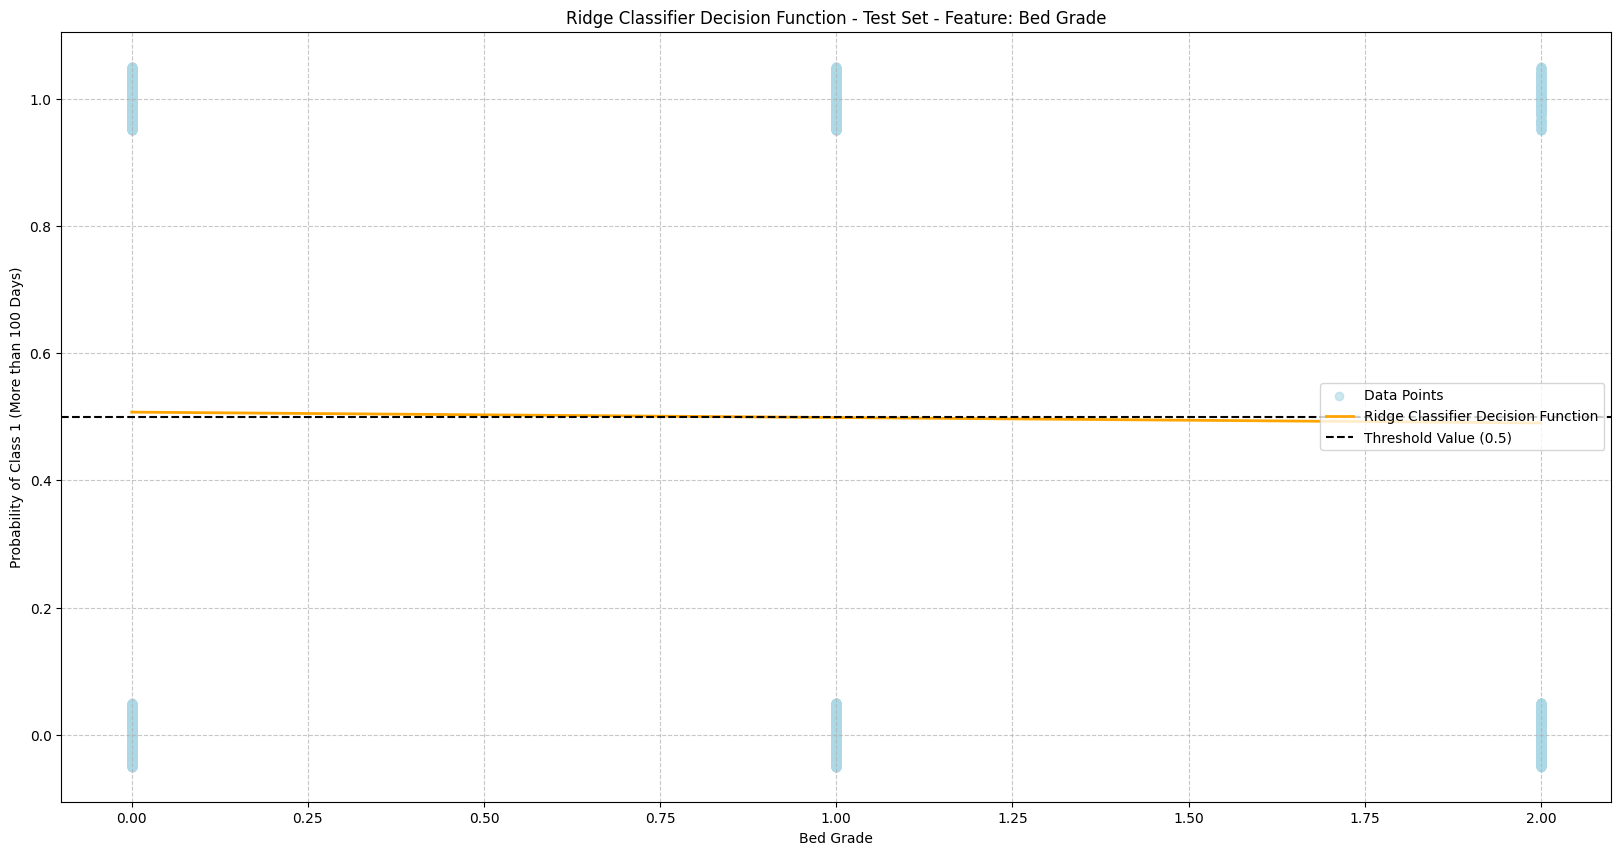

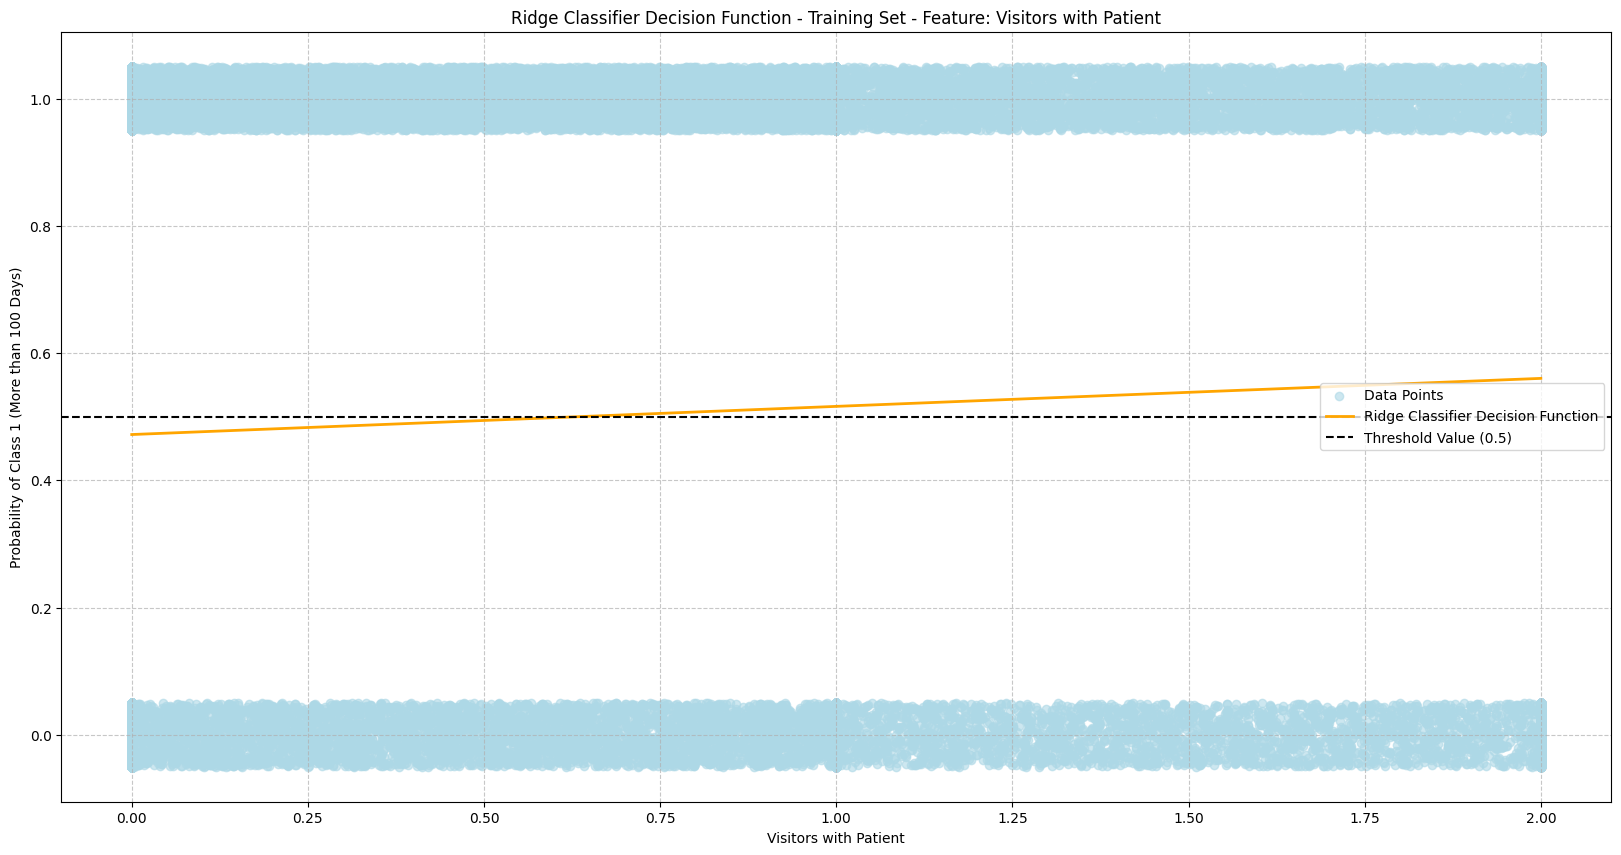

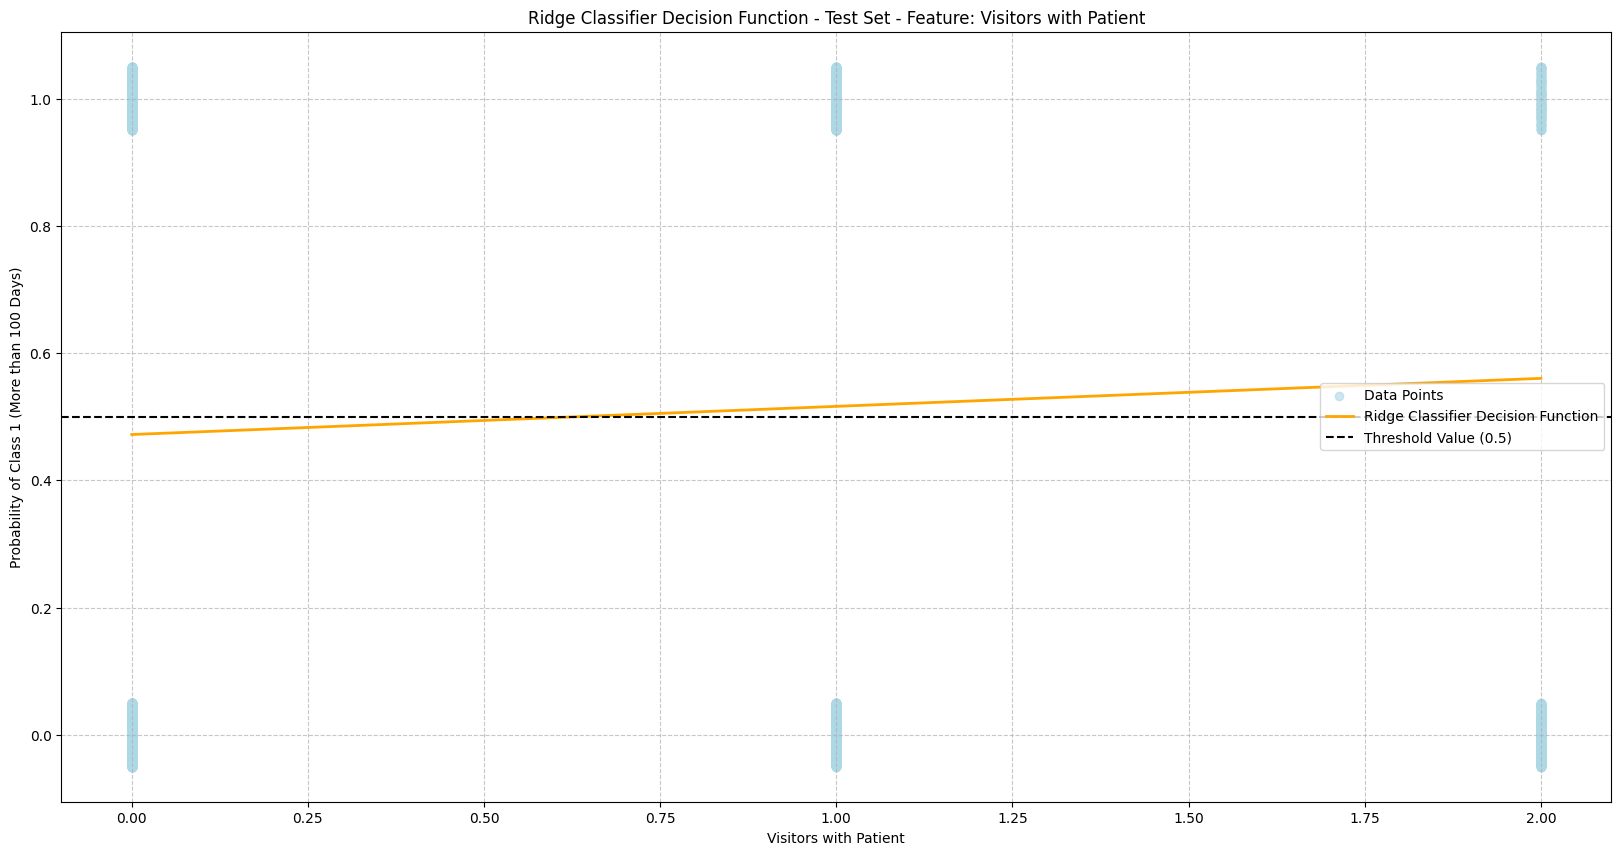

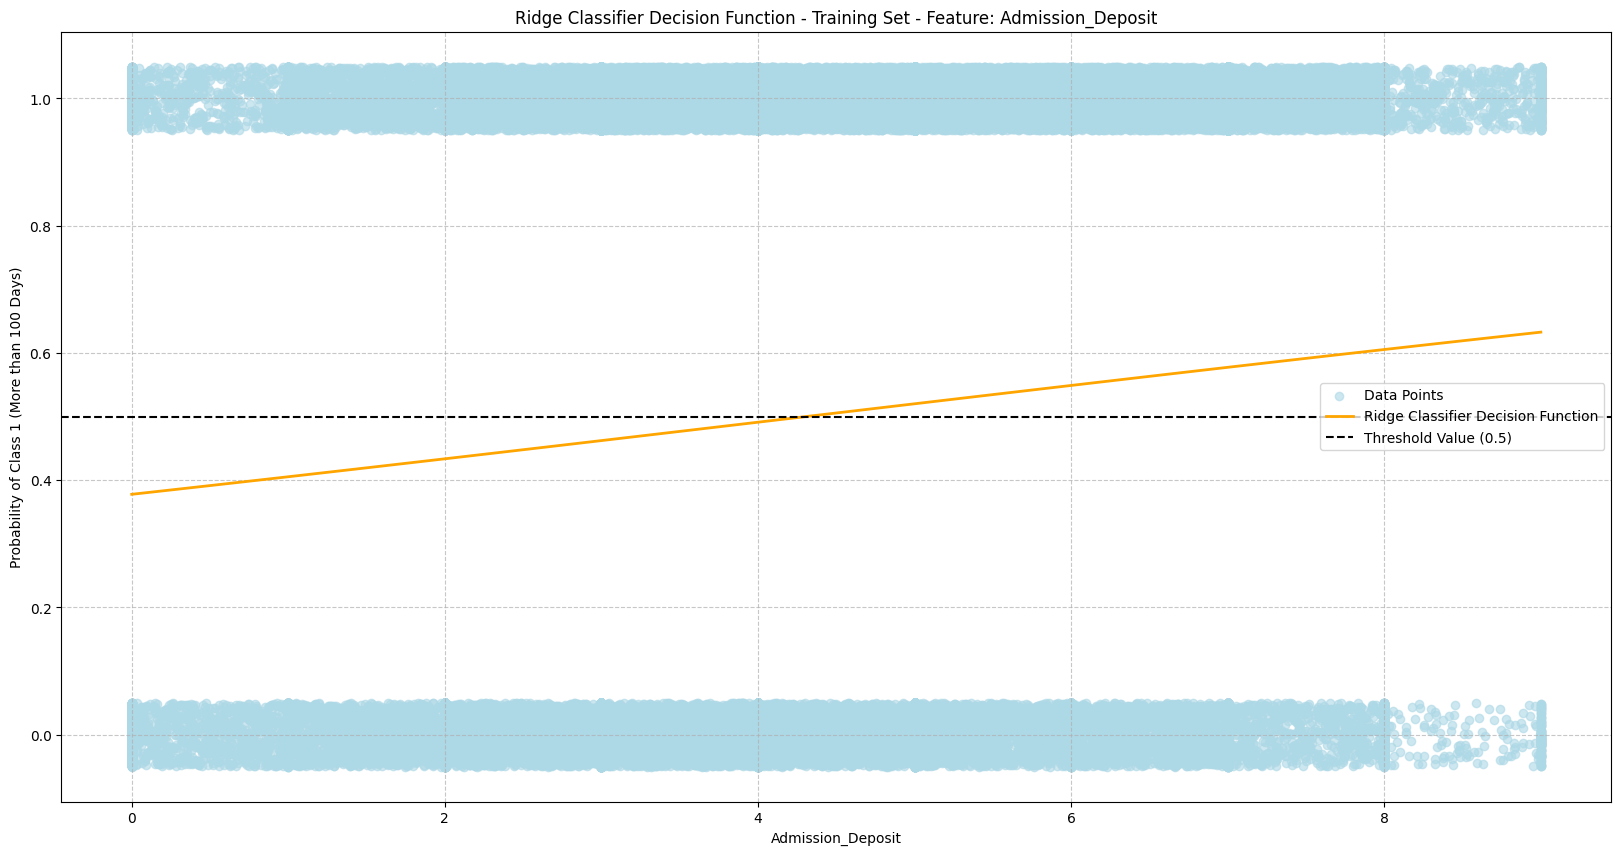

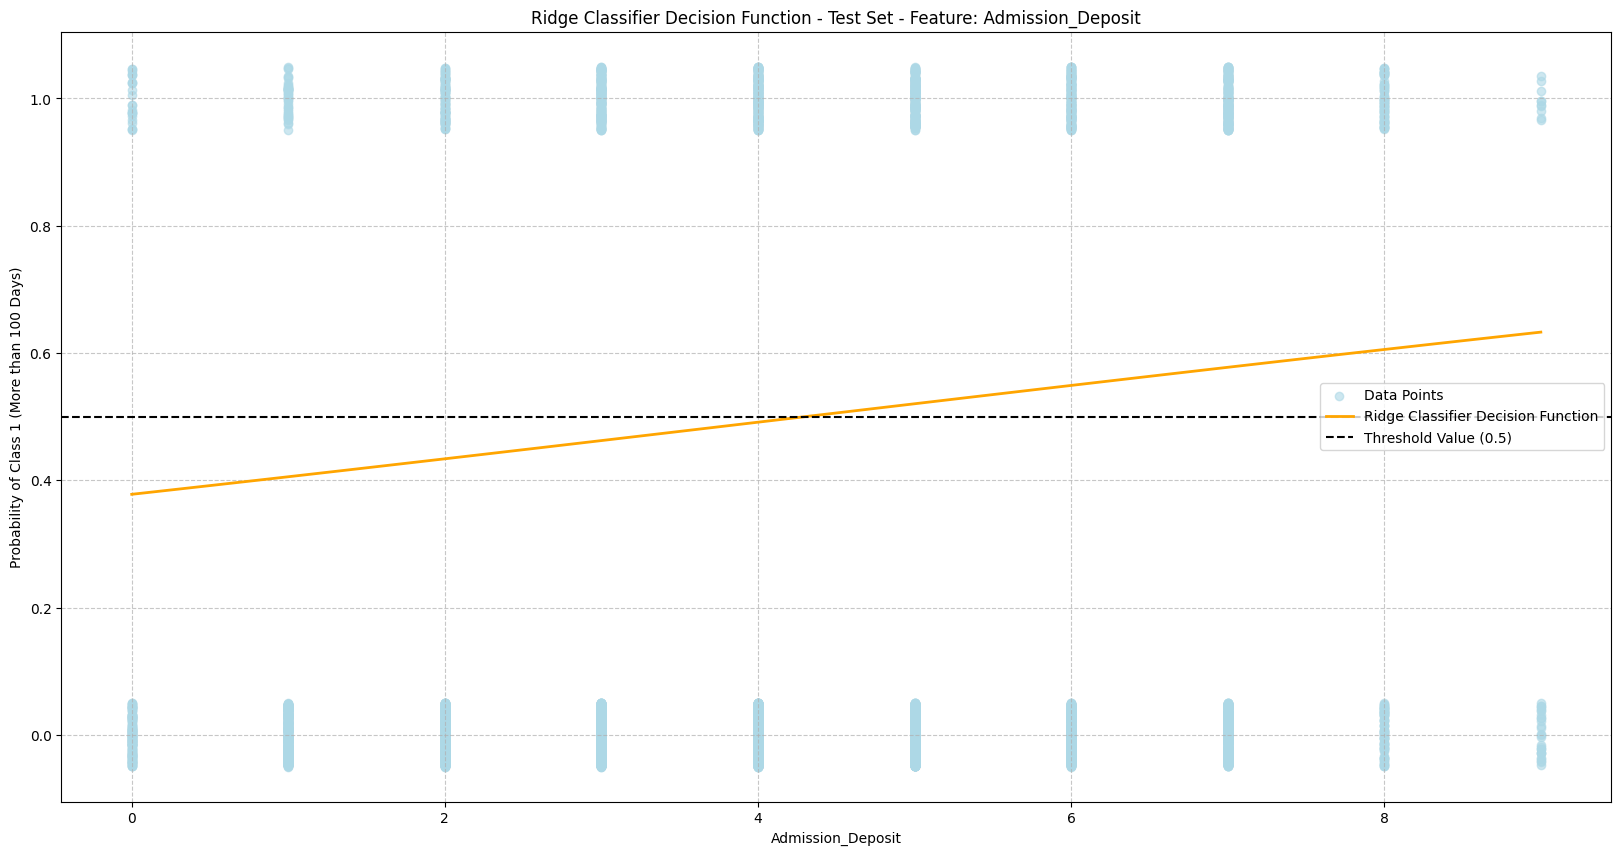

In [ ]:
class_labels = [
    "0-10 Days (0)", "11-20 Days (1)", "21-30 Days (2)", "31-40 Days (3)",
    "41-50 Days (4)", "51-60 Days (5)", "61-70 Days (6)", "71-80 Days (7)",
    "81-90 Days (8)", "91-100 Days (9)", "More than 100 Days (10)"
]

if not isinstance(x_train, pd.DataFrame):
    columns = [
        'Hospital_code', 'Hospital_type_code', 
        'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department',
        'Ward_Type', 'Bed Grade',
        'Type of Admission', 'Severity of Illness',
        'Visitors with Patient', 'Age', 'Admission_Deposit'
    ]
    x_train = pd.DataFrame(x_train, columns=columns)

if not isinstance(x_test, pd.DataFrame):
    columns = [
        'Hospital_code', 'Hospital_type_code', 
        'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department',
        'Ward_Type', 'Bed Grade',
        'Type of Admission', 'Severity of Illness',
        'Visitors with Patient', 'Age', 'Admission_Deposit'
    ]
    x_test = pd.DataFrame(x_test, columns=columns)

if not isinstance(y_train, pd.Series):
    y_train = pd.Series(y_train, name='Target')

if not isinstance(y_test, pd.Series):
    y_test = pd.Series(y_test, name='Target')

binary_classes = [0, 10]

mask_train = y_train.isin(binary_classes)
X_train_binary = x_train[mask_train]
y_train_binary = y_train[mask_train]

mask_test = y_test.isin(binary_classes)
X_test_binary = x_test[mask_test]
y_test_binary = y_test[mask_test]

y_train_binary = (y_train_binary == 10).astype(int)
y_test_binary = (y_test_binary == 10).astype(int)

numerical_features = [
    'Hospital_code', 'Available Extra Rooms in Hospital', 'Bed Grade',
    'Visitors with Patient', 'Admission_Deposit'
]

def plot_sigmoid_curve(X_1d, y_binary, feature, dataset_name):
    x_range = np.linspace(X_1d[feature].min(), X_1d[feature].max(), 100).reshape(-1, 1)
    decision_scores = model_1d.decision_function(x_range)

    probabilities = 1 / (1 + np.exp(-decision_scores))

    plt.figure(figsize=(20, 10))
    plt.scatter(X_1d[feature], y_binary + np.random.uniform(-0.05, 0.05, size=len(y_binary)), 
                color='lightblue', label='Data Points', alpha=0.6)
    plt.plot(x_range, probabilities, color='orange', label='Ridge Classifier Decision Function', linewidth=2)
    plt.axhline(y=0.5, color='black', linestyle='--', label='Threshold Value (0.5)')

    plt.xlabel(feature)
    plt.ylabel('Probability of Class 1 (More than 100 Days)')
    plt.title(f'Ridge Classifier Decision Function - {dataset_name} - Feature: {feature}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

for feature in numerical_features:
    if feature not in X_train_binary.columns:
        print(f"Feature '{feature}' is not in x_train. Skipping...")
        continue

    X_train_1d = X_train_binary[[feature]]
    X_test_1d = X_test_binary[[feature]]

    alpha = getattr(best_model_ridge, 'alpha', 1.0)
    model_1d = RidgeClassifier(alpha=alpha)

    model_1d.fit(X_train_1d, y_train_binary)

    plot_sigmoid_curve(X_train_1d, y_train_binary, feature, "Training Set")

    plot_sigmoid_curve(X_test_1d, y_test_binary, feature, "Test Set")

# Conclusion

This tutorial provides a complete, production-ready framework for applying the RidgeClassifier to multi-class problems using scikit-learn. The key components demonstrated include the construction of modular and clean preprocessing pipelines, the integration of SMOTE for imbalance handling within a safe workflow, the application of efficient Bayesian optimization for tuning, and the use of rigorous, interpretable metrics for model assessment. By consistently adhering to official scikit-learn patterns, this approach stands as a reliable reference for applying regularized linear models to complex, tabular datasets.

# References

- [RidgeClassifier Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeClassifier.html)
- [Ridge Classifier](https://www.geeksforgeeks.org/python/ridge-classifier/)
- [Ridge Regression and Classification: A Comprehensive Data Science Guide](https://medium.com/@rahultiwari065/ridge-regression-and-classification-a-comprehensive-data-science-guide-e14e95ccbb76)
- [Multiclass and multioutput algorithms](https://scikit-learn.org/stable/modules/multiclass.html)
- [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge)
- [Ridge regression and classification](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression)